## 0. Librerías

In [1]:
import ast
import hashlib
import json
import logging
import re
import warnings
from collections import Counter
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Union

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import TweetTokenizer

import scipy.sparse as sp
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.preprocessing import MinMaxScaler, normalize
from sentence_transformers import SentenceTransformer

try:
    import hdbscan
except ImportError:
    hdbscan = None

try:
    import umap
except ImportError:
    umap = None

try:
    import faiss
except ImportError:
    faiss = None

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

DATA_DIR   = Path('datasets/')
OUTPUT_DIR = Path('outputs/')
OUTPUT_DIR.mkdir(exist_ok=True)

print('Librerías OK')


Librerías OK


## 1. Carga de datasets

In [2]:
trump_df = pd.read_csv(DATA_DIR / 'hashtag_donaldtrump.csv', on_bad_lines='skip', engine='python')
biden_df = pd.read_csv(DATA_DIR / 'hashtag_joebiden.csv',    on_bad_lines='skip', engine='python')

trump_df['candidate'] = 'trump'
biden_df['candidate'] = 'biden'

election_df = pd.concat([trump_df, biden_df], ignore_index=True)
print(f'US Election 2020: {len(election_df):,} tweets')


US Election 2020: 1,748,160 tweets


In [3]:
twitter_df = pd.read_csv(DATA_DIR / 'twitter_dataset.csv',     on_bad_lines='skip', engine='python')
bot_df     = pd.read_csv(DATA_DIR / 'bot_detection_data.csv',  on_bad_lines='skip', engine='python')

with open(DATA_DIR / 'cleaned_twitter_elections_data.json', encoding='utf-8') as f:
    pakistan_raw = json.load(f)
pakistan_df = pd.DataFrame(pakistan_raw) if isinstance(pakistan_raw, list) else pd.json_normalize(pakistan_raw)

print(f'Twitter general: {len(twitter_df):,} registros')
print(f'Bot detection:   {len(bot_df):,} registros')
print(f'Pakistan 2018:   {len(pakistan_df):,} registros')


Twitter general: 10,000 registros
Bot detection:   50,000 registros
Pakistan 2018:   29,579 registros


## 2. Limpieza de datos
### 2.1 Selección y renombrado de columnas

In [4]:
COLS_ELECTION = {
    'tweet_id':             'tweet_id',
    'tweet':                'text',
    'created_at':           'created_at',
    'user_id':              'user_id',
    'user_screen_name':     'user_screen_name',
    'user_followers_count': 'followers_count',
    'user_join_date':       'user_join_date',
    'likes':                'likes',
    'retweet_count':        'retweet_count',
    'source':               'source',
    'user_location':        'user_location',
    'state':                'state',
    'country':              'country',
    'candidate':            'candidate',
}

df = (
    election_df[[c for c in COLS_ELECTION if c in election_df.columns]]
    .rename(columns=COLS_ELECTION)
)
print(f'Columnas: {df.columns.tolist()}')


Columnas: ['tweet_id', 'text', 'created_at', 'user_id', 'user_screen_name', 'followers_count', 'user_join_date', 'likes', 'retweet_count', 'source', 'user_location', 'state', 'country', 'candidate']


In [5]:
df.head()

,tweet_id,text,created_at,user_id,user_screen_name,followers_count,user_join_date,likes,retweet_count,source,user_location,state,country,candidate
0,1.316529221557252e+18,#Elecciones2020 | En #Florida: #JoeBiden dice ...,2020-10-15 00:00:01,360666534.0,elsollatinonews,1860.0,2011-08-23 15:33:45,0.0,0.0,TweetDeck,"Philadelphia, PA / Miami, FL",Florida,United States of America,trump
1,1.3165292227484303e+18,"Usa 2020, Trump contro Facebook e Twitter: cop...",2020-10-15 00:00:01,331617619.0,MediasetTgcom24,1067661.0,2011-07-08 13:12:20,26.0,9.0,Social Mediaset,NaN,NaN,NaN,trump
2,1.316529228091847e+18,"#Trump: As a student I used to hear for years,...",2020-10-15 00:00:02,8436472.0,snarke,1185.0,2007-08-26 05:56:11,2.0,1.0,Twitter Web App,Portland,Oregon,United States of America,trump
3,1.316529227471237e+18,2 hours since last tweet from #Trump! Maybe he...,2020-10-15 00:00:02,8.28355589206057e+17,trumpytweeter,32.0,2017-02-05 21:32:17,0.0,0.0,Trumpytweeter,NaN,NaN,NaN,trump
4,1.3165292523014513e+18,You get a tie! And you get a tie! #Trump ‘s ra...,2020-10-15 00:00:08,47413798.0,Ranaabtar,5393.0,2009-06-15 19:05:35,4.0,3.0,Twitter for iPhone,Washington DC,District of Columbia,United States of America,trump


### 2.2 Duplicados

In [6]:
n_before = len(df)
df = df.drop_duplicates(subset='tweet_id')
print(f'Duplicados eliminados: {n_before - len(df):,} | Restantes: {len(df):,}')


Duplicados eliminados: 225,215 | Restantes: 1,522,945


### 2.3 Valores faltantes

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing': missing, 'pct': missing_pct}).query('missing > 0')


,missing,pct
tweet_id,1,0.00
text,1,0.00
user_id,38,0.00
user_screen_name,34,0.00
followers_count,250,0.02
user_join_date,280,0.02
likes,20,0.00
retweet_count,34,0.00
source,1009,0.07
user_location,462967,30.40


In [8]:
df = df.dropna(subset=['text', 'created_at'])

for col in ['likes', 'retweet_count', 'followers_count']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

for col in ['user_location', 'state', 'country', 'source']:
    df[col] = df[col].fillna('unknown')

print(f'Registros finales: {len(df):,}')


Registros finales: 1,522,944


## 3. Normalización temporal

In [9]:
def parse_datetime_robust(series: pd.Series) -> pd.Series:
    """
    Parse a datetime series that may contain either unix-epoch numbers or ISO strings.
    Detects the format from a sample and applies the appropriate conversion.
    """
    sample = pd.to_numeric(series.dropna().head(100), errors='coerce').dropna()
    if len(sample) > 0:
        median = sample.median()
        # Unix epoch in seconds: ~1.58e9 for year 2020
        # Unix epoch in milliseconds: ~1.58e12
        unit = 'ms' if median > 1e11 else 's'
        print(f'  Detectado: unix epoch (unit={unit!r})')
        return pd.to_datetime(pd.to_numeric(series, errors='coerce'), unit=unit, utc=True, errors='coerce')

    print('  Detectado: strings ISO')
    return pd.to_datetime(series, utc=True, errors='coerce')


print('Parseando created_at...')
df['created_at'] = parse_datetime_robust(df['created_at'])
df = df.dropna(subset=['created_at'])

df['date']        = df['created_at'].dt.date
df['hour']        = df['created_at'].dt.hour
df['day_of_week'] = df['created_at'].dt.dayofweek
df['week']        = df['created_at'].dt.isocalendar().week.astype(int)
df['hour_window'] = df['created_at'].dt.floor('1h')

print(f'Rango temporal: {df["created_at"].min().date()} → {df["created_at"].max().date()}')


Parseando created_at...
  Detectado: strings ISO
Rango temporal: 2020-10-15 → 2020-11-08


In [10]:
if 'user_join_date' in df.columns:
    df['user_join_date']   = parse_datetime_robust(df['user_join_date'])
    df['account_age_days'] = (df['created_at'] - df['user_join_date']).dt.days.clip(lower=0)
else:
    df['account_age_days'] = np.nan

print('account_age_days OK')


  Detectado: strings ISO
account_age_days OK


## 4. Preprocesamiento textual

In [11]:
tokenizer  = TweetTokenizer(preserve_case=False, reduce_len=True, strip_handles=False)
lemmatizer = WordNetLemmatizer()
STOP_EN    = set(stopwords.words('english'))


def extract_hashtags(text: str) -> List[str]:
    return re.findall(r'#(\w+)', str(text).lower())


def extract_mentions(text: str) -> List[str]:
    return re.findall(r'@(\w+)', str(text).lower())


def is_retweet(text: str) -> bool:
    return str(text).strip().startswith('RT @')


def clean_text(text: str) -> str:
    text = re.sub(r'http\S+|www\S+', '', str(text))
    text = re.sub(r'RT\s@\w+:', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^\w\s#]', '', text)
    tokens = [
        lemmatizer.lemmatize(t)
        for t in tokenizer.tokenize(text)
        if t not in STOP_EN and len(t) > 2 and not t.startswith('#')
    ]
    return ' '.join(tokens)


print('Funciones de texto definidas')


Funciones de texto definidas


In [12]:
df['hashtags']   = df['text'].apply(extract_hashtags)
df['mentions']   = df['text'].apply(extract_mentions)
df['is_retweet'] = df['text'].apply(is_retweet).astype(int)
df['n_hashtags'] = df['hashtags'].apply(len)
df['n_mentions'] = df['mentions'].apply(len)

print('Limpiando texto (puede tardar unos minutos)...')
df['text_clean'] = df['text'].apply(clean_text)
print('Texto limpiado')


Limpiando texto (puede tardar unos minutos)...
Texto limpiado


## 5. Feature Engineering
### 5.1 Actividad por cuenta

In [13]:
for col in ['likes', 'retweet_count', 'n_hashtags']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

user_activity = (
    df.groupby('user_id')
    .agg(
        total_tweets   = ('tweet_id',     'count'),
        total_retweets = ('is_retweet',   'sum'),
        unique_days    = ('date',         'nunique'),
        avg_likes      = ('likes',        'mean'),
        avg_rt         = ('retweet_count', 'mean'),
        avg_hashtags   = ('n_hashtags',   'mean'),
    )
    .reset_index()
)
user_activity['retweet_ratio'] = (
    user_activity['total_retweets'] / user_activity['total_tweets'].clip(lower=1)
)

df = df.merge(user_activity, on='user_id', how='left')
print(f'Cuentas únicas: {len(user_activity):,}')


Cuentas únicas: 483,189


### 5.2 Densidad temporal por ventana de 1 hora

In [14]:
window_activity = (
    df.groupby('hour_window')
    .agg(
        tweets_in_window       = ('tweet_id',   'count'),
        unique_users_in_window = ('user_id',    'nunique'),
        rt_in_window           = ('is_retweet', 'sum'),
    )
    .reset_index()
)
window_activity['rt_ratio_window'] = (
    window_activity['rt_in_window'] / window_activity['tweets_in_window'].clip(lower=1)
)

df = df.merge(window_activity, on='hour_window', how='left')
print('Features de ventana temporal creadas')


Features de ventana temporal creadas


### 5.3 Muestra estratificada

In [15]:
SAMPLE_N = 200_000

trump_sample = df[df['candidate'] == 'trump'].sample(
    min(len(df[df['candidate'] == 'trump']), SAMPLE_N // 2), random_state=42)
biden_sample = df[df['candidate'] == 'biden'].sample(
    min(len(df[df['candidate'] == 'biden']), SAMPLE_N // 2), random_state=42)

df_sample = pd.concat([trump_sample, biden_sample]).reset_index(drop=True)

print(f'Muestra de trabajo: {len(df_sample):,} tweets')
print(df_sample['candidate'].value_counts())


Muestra de trabajo: 200,000 tweets
candidate
trump    100000
biden    100000
Name: count, dtype: int64


### 5.4 Vectorización TF-IDF

In [16]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=5, max_df=0.95, sublinear_tf=True)
tfidf_matrix = tfidf.fit_transform(df_sample['text_clean'])
print(f'Matriz TF-IDF: {tfidf_matrix.shape}')


Matriz TF-IDF: (200000, 5000)


### 5.5 Feature tabular escalada

In [17]:
NUMERIC_FEATURES = [
    'followers_count', 'likes', 'retweet_count',
    'n_hashtags', 'n_mentions', 'is_retweet',
    'hour', 'day_of_week', 'account_age_days',
    'total_tweets', 'retweet_ratio', 'avg_likes',
    'tweets_in_window', 'unique_users_in_window', 'rt_ratio_window',
]
NUMERIC_FEATURES = [c for c in NUMERIC_FEATURES if c in df_sample.columns]

features_scaled = MinMaxScaler().fit_transform(df_sample[NUMERIC_FEATURES].fillna(0))
features_scaled_df = pd.DataFrame(features_scaled, columns=NUMERIC_FEATURES)

print(f'Feature matrix: {features_scaled_df.shape}')
features_scaled_df.describe().T[['mean', 'std', 'min', 'max']]


Feature matrix: (200000, 15)


,mean,std,min,max
followers_count,0.000279,0.004656,0.0,1.0
likes,0.000235,0.005073,0.0,1.0
retweet_count,0.000177,0.004543,0.0,1.0
n_hashtags,0.095218,0.087246,0.0,1.0
n_mentions,0.013535,0.035903,0.0,1.0
is_retweet,0.000125,0.011180,0.0,1.0
hour,0.540038,0.311537,0.0,1.0
day_of_week,0.578211,0.307024,0.0,1.0
account_age_days,0.428104,0.289498,0.0,1.0
total_tweets,0.037266,0.096656,0.0,1.0


## 6. Detección preliminar de anomalías

In [18]:
# P95 es el umbral operativo; P99 se calcula para referencia comparativa
p95 = window_activity['tweets_in_window'].quantile(0.95)
p99 = window_activity['tweets_in_window'].quantile(0.99)
print(f'Tweets por ventana — P95: {p95:.0f} | P99: {p99:.0f}')

burst_windows = window_activity[window_activity['tweets_in_window'] >= p95].copy()
print(f'Ventanas con burst (>= P95): {len(burst_windows):,}')
burst_windows.sort_values('tweets_in_window', ascending=False).head(10)


Tweets por ventana — P95: 7170 | P99: 14661
Ventanas con burst (>= P95): 30


,hour_window,tweets_in_window,unique_users_in_window,rt_in_window,rt_ratio_window
569,2020-11-07 17:00:00+00:00,46416,39072,4,0.000086
568,2020-11-07 16:00:00+00:00,38179,32747,1,0.000026
570,2020-11-07 18:00:00+00:00,28653,24302,7,0.000244
571,2020-11-07 19:00:00+00:00,19022,16157,4,0.000210
194,2020-10-23 02:00:00+00:00,17445,10188,2,0.000115
193,2020-10-23 01:00:00+00:00,16199,8467,0,0.000000
572,2020-11-07 20:00:00+00:00,14645,12184,1,0.000068
573,2020-11-07 21:00:00+00:00,12708,10498,0,0.000000
487,2020-11-04 07:00:00+00:00,12387,9231,0,0.000000
577,2020-11-08 01:00:00+00:00,12343,9458,0,0.000000


## 7. Guardado de artefactos (A3)

In [19]:
df_sample.to_csv(OUTPUT_DIR / 'df_processed_sample.csv', index=False)
features_scaled_df.to_csv(OUTPUT_DIR / 'features_scaled.csv', index=False)
burst_windows.to_csv(OUTPUT_DIR / 'burst_windows.csv', index=False)
sp.save_npz(OUTPUT_DIR / 'tfidf_matrix.npz', tfidf_matrix)
print('Artefactos guardados en outputs/')


Artefactos guardados en outputs/


## 8. Resumen general del dataset

In [20]:
print('=== Resumen general ===')
print(f"Tweets totales:     {len(df_sample):,}")
print(f"Cuentas únicas:     {df_sample['user_id'].nunique():,}")
print(f"Período:            {df_sample['created_at'].min().date()} → {df_sample['created_at'].max().date()}")
print(f"Retweets:           {df_sample['is_retweet'].sum():,} ({df_sample['is_retweet'].mean()*100:.1f}%)")
print(f"Con hashtag:        {(df_sample['n_hashtags'] > 0).sum():,} ({(df_sample['n_hashtags'] > 0).mean()*100:.1f}%)")
print()
print('--- Por candidato ---')
print(df_sample['candidate'].value_counts())


=== Resumen general ===
Tweets totales:     200,000
Cuentas únicas:     116,495
Período:            2020-10-15 → 2020-11-08
Retweets:           25 (0.0%)
Con hashtag:        199,984 (100.0%)

--- Por candidato ---
candidate
trump    100000
biden    100000
Name: count, dtype: int64


In [21]:
desc_cols = [c for c in [
    'likes', 'retweet_count', 'followers_count', 'n_hashtags',
    'n_mentions', 'account_age_days', 'total_tweets', 'retweet_ratio',
] if c in df_sample.columns]
df_sample[desc_cols].describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
likes,200000.0,9.00,194.03,0.0,0.0,0.0,2.0,38248.0
retweet_count,200000.0,2.02,51.83,0.0,0.0,0.0,0.0,11407.0
followers_count,200000.0,22966.34,383738.79,0.0,74.0,423.0,2009.0,82417099.0
n_hashtags,200000.0,3.81,3.49,0.0,2.0,3.0,5.0,40.0
n_mentions,200000.0,0.68,1.80,0.0,0.0,0.0,1.0,50.0
account_age_days,199969.0,2238.05,1513.07,0.0,676.0,2427.0,3622.0,5227.0
total_tweets,199999.0,50.38,130.68,1.0,2.0,8.0,37.0,1352.0
retweet_ratio,199999.0,0.00,0.01,0.0,0.0,0.0,0.0,1.0


## 9. Distribución temporal
### 9.1 Tweets por día

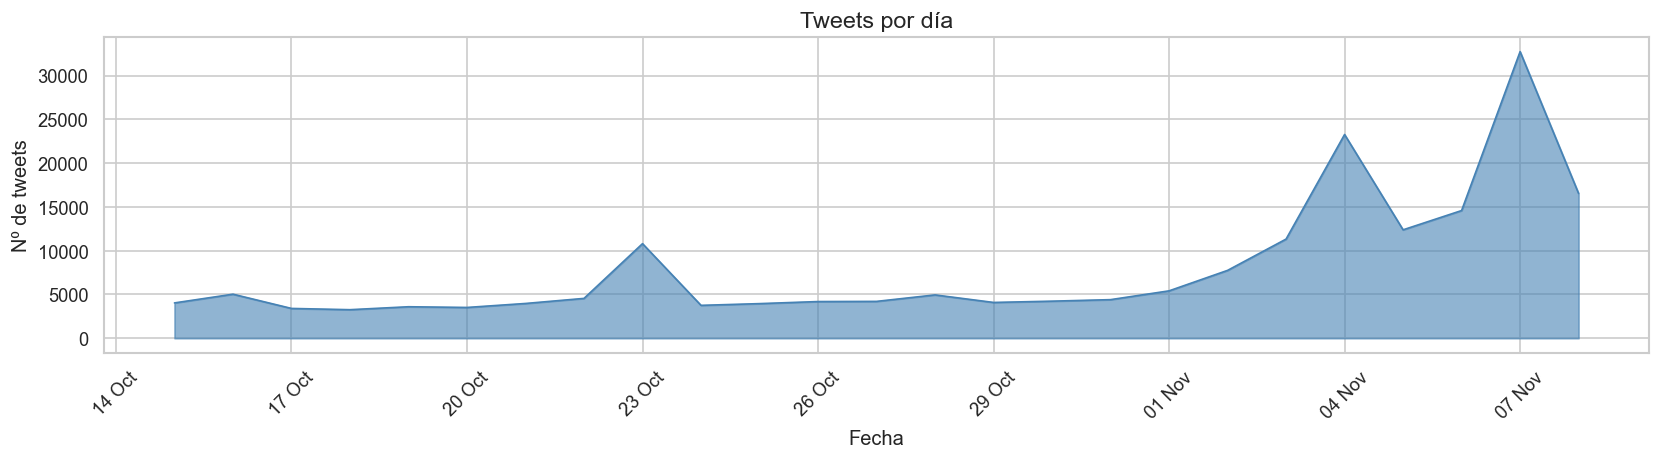

In [22]:
daily = df_sample.groupby('date').size().reset_index(name='tweets')
daily['date'] = pd.to_datetime(daily['date'])

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(daily['date'], daily['tweets'], alpha=0.6, color='steelblue')
ax.plot(daily['date'], daily['tweets'], color='steelblue', linewidth=1)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=45)
ax.set_title('Tweets por día', fontsize=14)
ax.set_xlabel('Fecha')
ax.set_ylabel('Nº de tweets')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_tweets_por_dia.png')
plt.show()


### 9.2 Tweets por hora del día

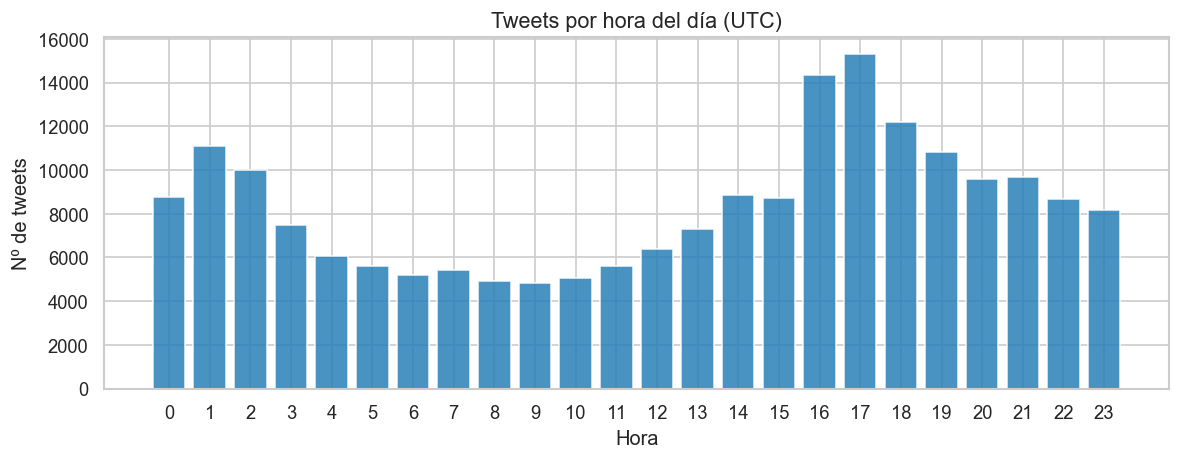

In [23]:
hourly = df_sample.groupby('hour').size().reset_index(name='tweets')

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(hourly['hour'], hourly['tweets'], color='#2980B9', alpha=0.85, edgecolor='white')
ax.set_title('Tweets por hora del día (UTC)', fontsize=13)
ax.set_xlabel('Hora')
ax.set_ylabel('Nº de tweets')
ax.set_xticks(range(24))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_tweets_por_hora.png')
plt.show()


### 9.3 Mapa de calor: actividad hora × día de la semana

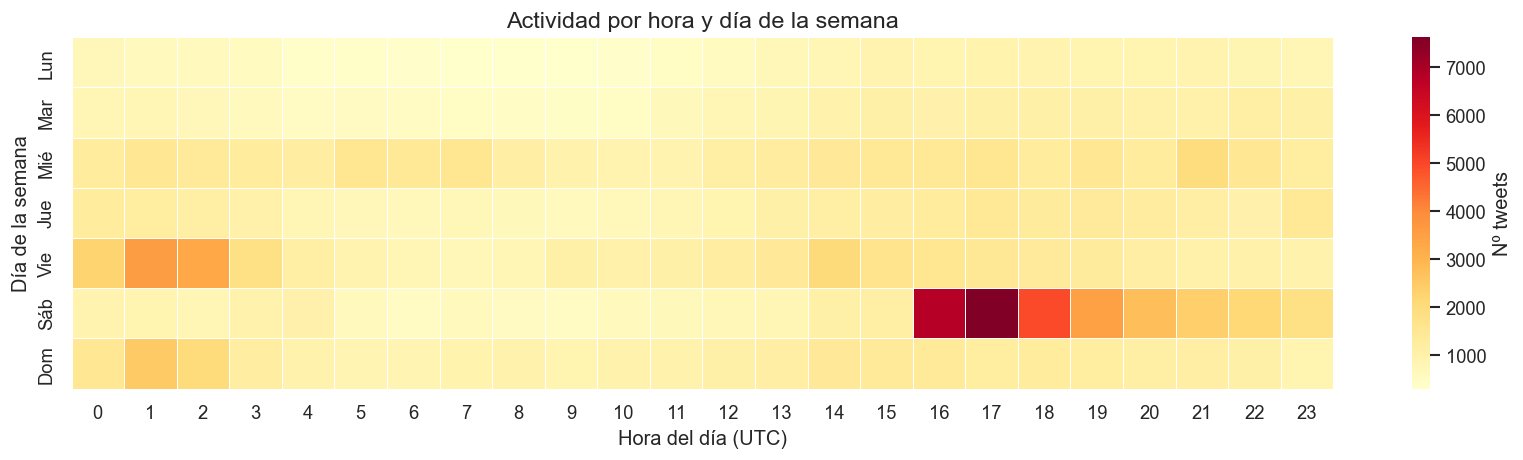

In [24]:
heatmap_data = df_sample.groupby(['day_of_week', 'hour']).size().unstack(fill_value=0)
heatmap_data.index = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax, linewidths=0.3, cbar_kws={'label': 'Nº tweets'})
ax.set_title('Actividad por hora y día de la semana', fontsize=14)
ax.set_xlabel('Hora del día (UTC)')
ax.set_ylabel('Día de la semana')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_heatmap_hora_dia.png')
plt.show()


### 9.4 Ventanas con burst de actividad (top 20)

2026-06-24 21:34:29,064 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-24 21:34:29,067 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


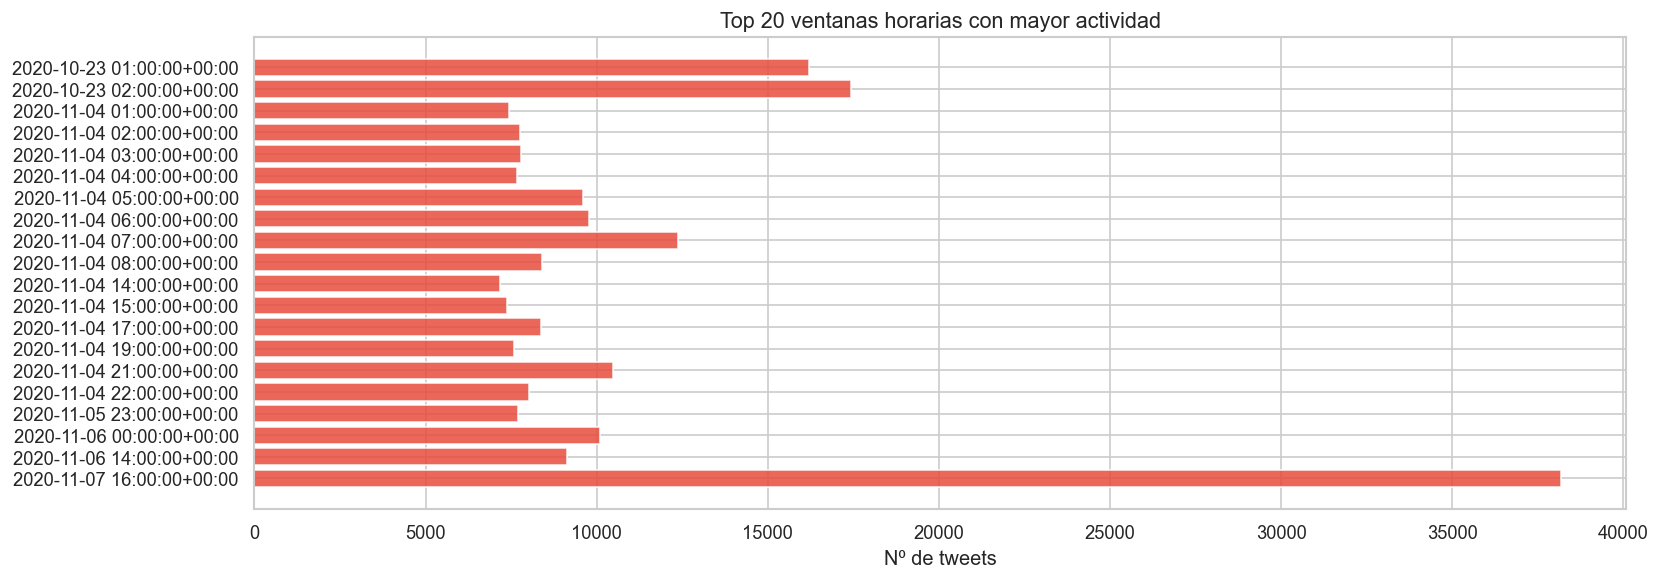

In [25]:
top20 = burst_windows.head(20)

fig, ax = plt.subplots(figsize=(14, 5))
ax.barh(top20['hour_window'].astype(str), top20['tweets_in_window'], color='#E74C3C', alpha=0.85)
ax.set_title('Top 20 ventanas horarias con mayor actividad', fontsize=13)
ax.set_xlabel('Nº de tweets')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_burst_windows.png')
plt.show()


## 10. Análisis de cuentas
### 10.1 Distribución de tweets por cuenta

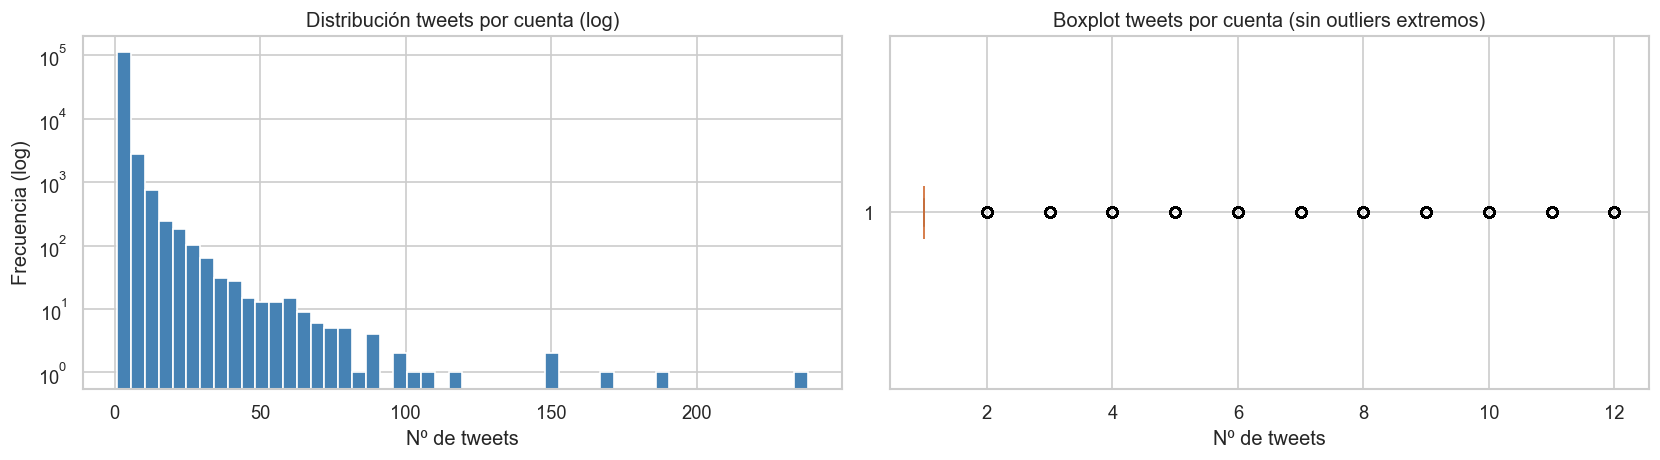

Cuentas con 1 tweet:      90,115
Cuentas con > 50 tweets:  78
Cuentas con > 100 tweets: 8


In [26]:
tweets_per_user = df_sample.groupby('user_id').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(tweets_per_user, bins=50, color='steelblue', edgecolor='white', log=True)
axes[0].set_title('Distribución tweets por cuenta (log)', fontsize=12)
axes[0].set_xlabel('Nº de tweets')
axes[0].set_ylabel('Frecuencia (log)')

axes[1].boxplot(
    tweets_per_user.clip(upper=tweets_per_user.quantile(0.99)),
    vert=False, patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.7),
)
axes[1].set_title('Boxplot tweets por cuenta (sin outliers extremos)', fontsize=12)
axes[1].set_xlabel('Nº de tweets')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_tweets_por_cuenta.png')
plt.show()

print(f'Cuentas con 1 tweet:      {(tweets_per_user == 1).sum():,}')
print(f'Cuentas con > 50 tweets:  {(tweets_per_user > 50).sum():,}')
print(f'Cuentas con > 100 tweets: {(tweets_per_user > 100).sum():,}')


### 10.2 Retweet ratio por cuenta

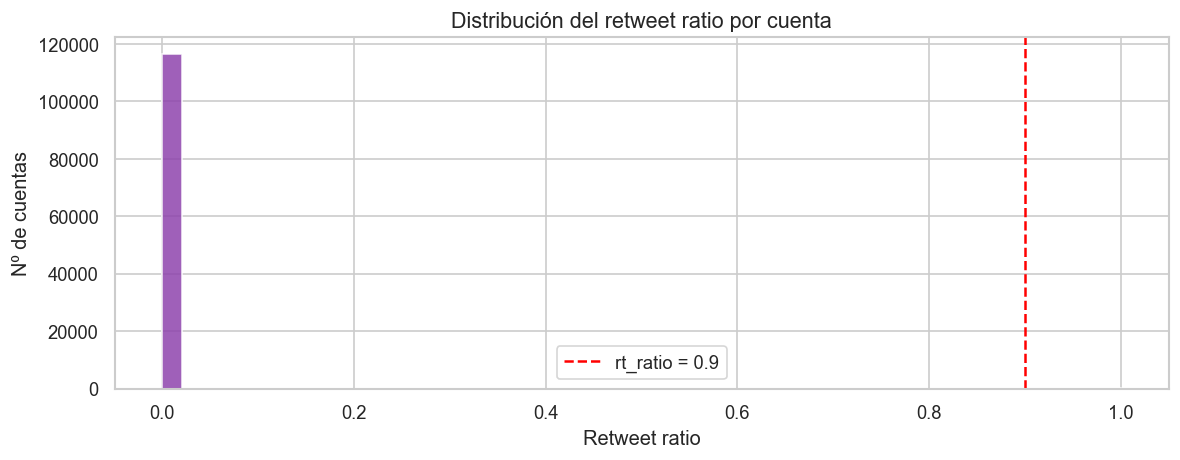

Cuentas con rt_ratio >= 0.9: 14 (0.0%)


In [27]:
user_stats = (
    df_sample.groupby('user_id')
    .agg(total=('tweet_id', 'count'), rts=('is_retweet', 'sum'))
    .reset_index()
)
user_stats['rt_ratio'] = user_stats['rts'] / user_stats['total'].clip(lower=1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(user_stats['rt_ratio'], bins=50, color='#8E44AD', edgecolor='white', alpha=0.85)
ax.axvline(0.9, color='red', linestyle='--', label='rt_ratio = 0.9')
ax.set_title('Distribución del retweet ratio por cuenta', fontsize=13)
ax.set_xlabel('Retweet ratio')
ax.set_ylabel('Nº de cuentas')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_retweet_ratio.png')
plt.show()

high_rt = (user_stats['rt_ratio'] >= 0.9).sum()
print(f'Cuentas con rt_ratio >= 0.9: {high_rt:,} ({high_rt / len(user_stats) * 100:.1f}%)')


### 10.3 Antigüedad de cuenta

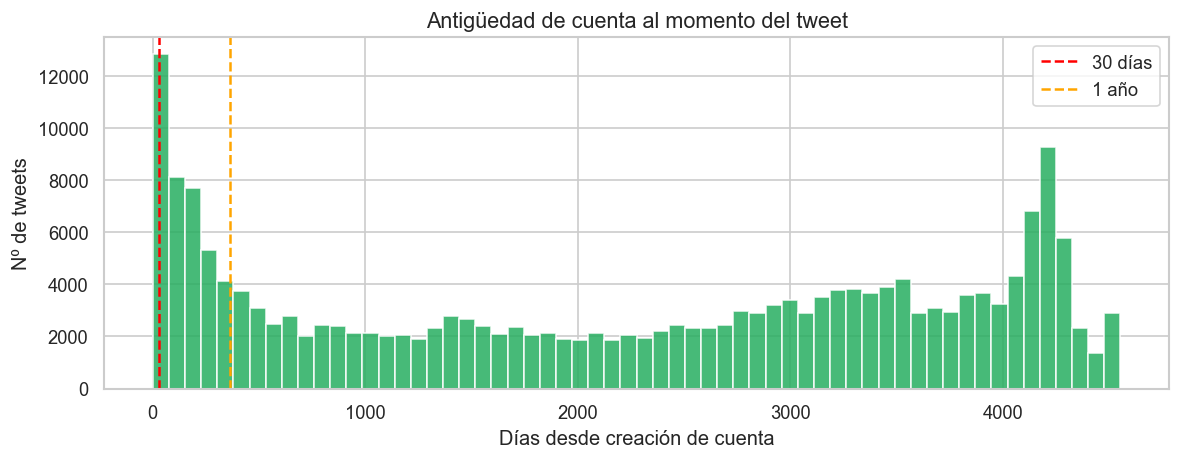

Tweets de cuentas con <= 30 días: 6,824 (3.4%)


In [28]:
if 'account_age_days' in df_sample.columns:
    age = df_sample['account_age_days'].dropna()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(age.clip(upper=age.quantile(0.99)), bins=60, color='#27AE60', edgecolor='white', alpha=0.85)
    ax.axvline(30,  color='red',    linestyle='--', label='30 días')
    ax.axvline(365, color='orange', linestyle='--', label='1 año')
    ax.set_title('Antigüedad de cuenta al momento del tweet', fontsize=13)
    ax.set_xlabel('Días desde creación de cuenta')
    ax.set_ylabel('Nº de tweets')
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'eda_antiguedad_cuenta.png')
    plt.show()

    nuevas = (age <= 30).sum()
    print(f'Tweets de cuentas con <= 30 días: {nuevas:,} ({nuevas / len(age) * 100:.1f}%)')


## 11. Análisis de contenido
### 11.1 Hashtags más frecuentes

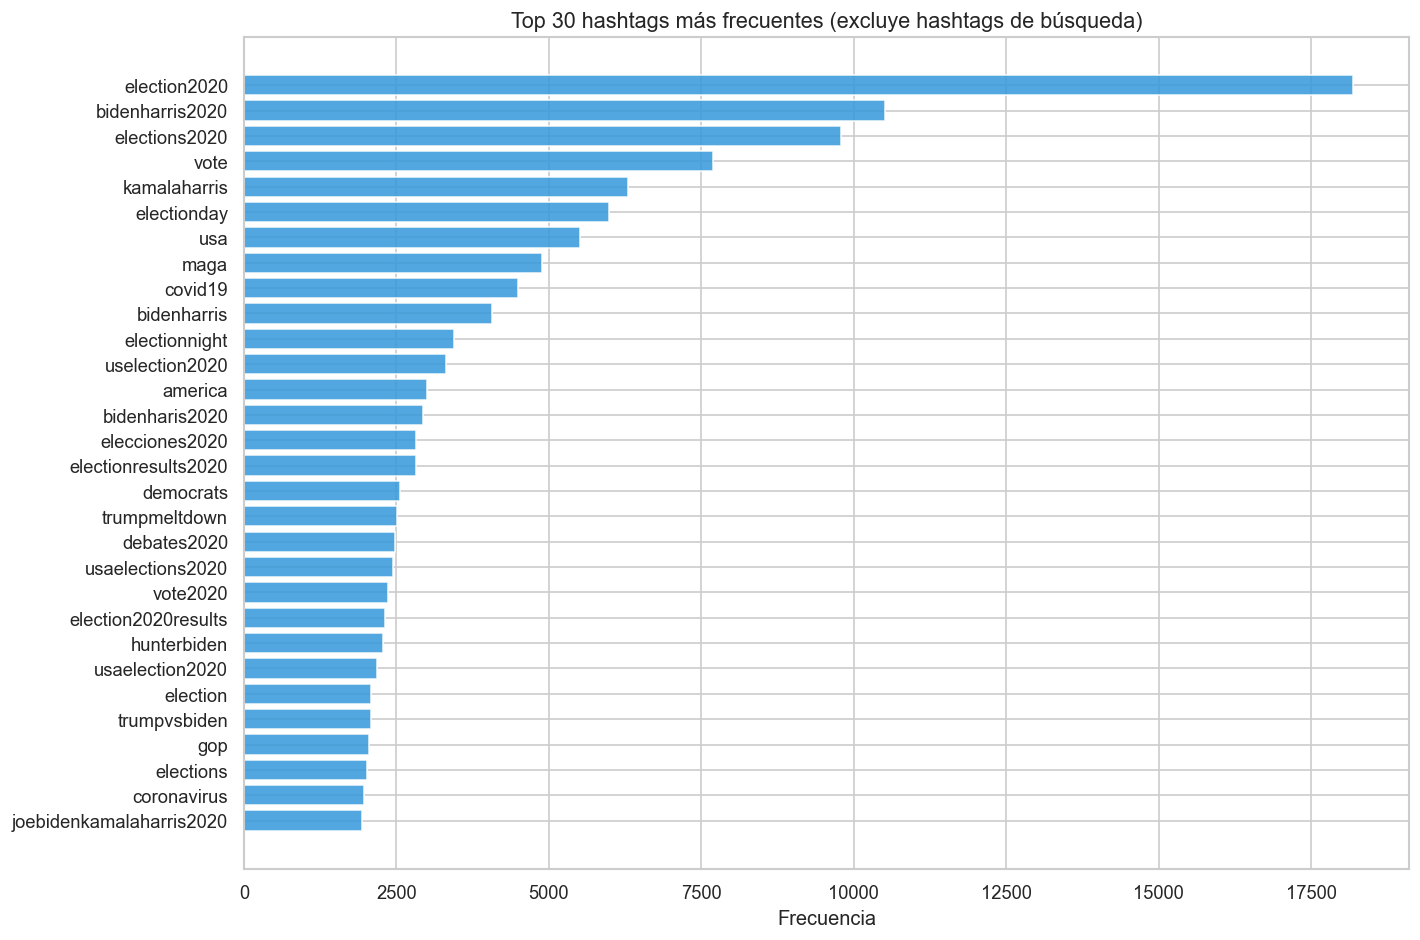

In [29]:
all_hashtags   = [ht for lista in df_sample['hashtags'] for ht in lista]
hashtag_counts = Counter(all_hashtags)
exclude        = {'donaldtrump', 'trump', 'joebiden', 'biden', 'trump2020', 'biden2020'}
top_ht         = [(k, v) for k, v in hashtag_counts.most_common(50) if k not in exclude][:30]

labels, values = zip(*top_ht)
fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(labels, values, color='#3498DB', alpha=0.85)
ax.invert_yaxis()
ax.set_title('Top 30 hashtags más frecuentes (excluye hashtags de búsqueda)', fontsize=13)
ax.set_xlabel('Frecuencia')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_top_hashtags.png')
plt.show()


### 11.2 Distribución de likes y retweets

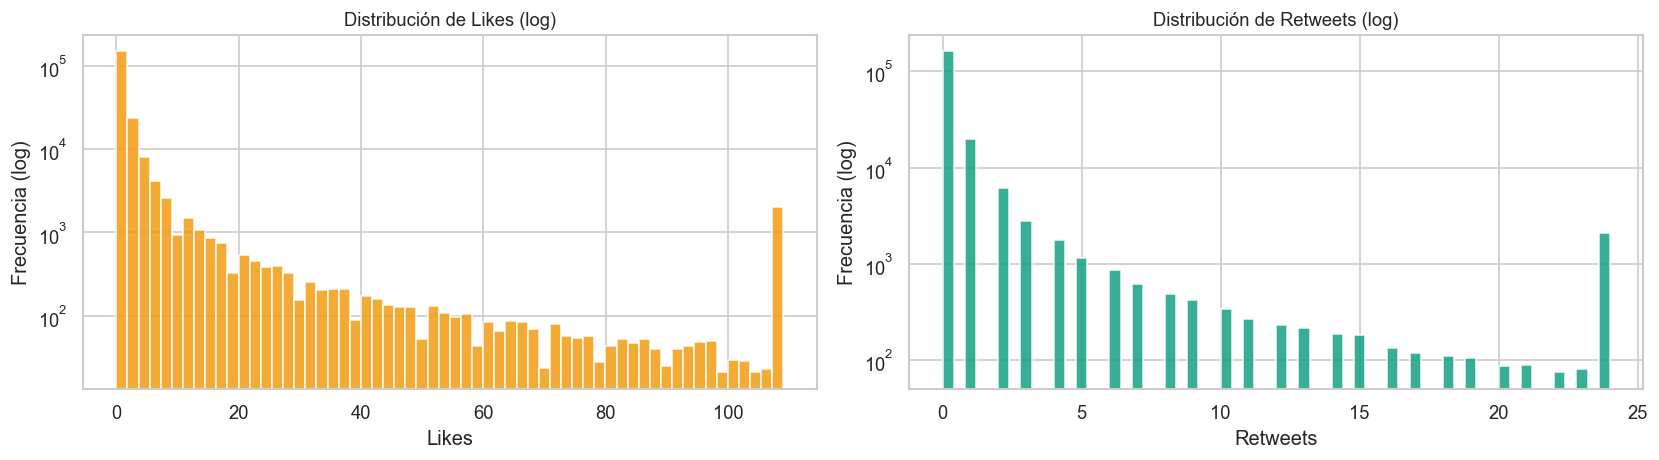

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, color, label in [
    (axes[0], 'likes',         '#F39C12', 'Likes'),
    (axes[1], 'retweet_count', '#16A085', 'Retweets'),
]:
    data = df_sample[col].dropna()
    ax.hist(data.clip(upper=data.quantile(0.99)), bins=60, color=color, edgecolor='white', alpha=0.85, log=True)
    ax.set_title(f'Distribución de {label} (log)', fontsize=11)
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia (log)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_likes_retweets.png')
plt.show()


## 12. Señales de coordinación preliminares
### 12.1 Cuentas que tuitean en múltiples ventanas de burst

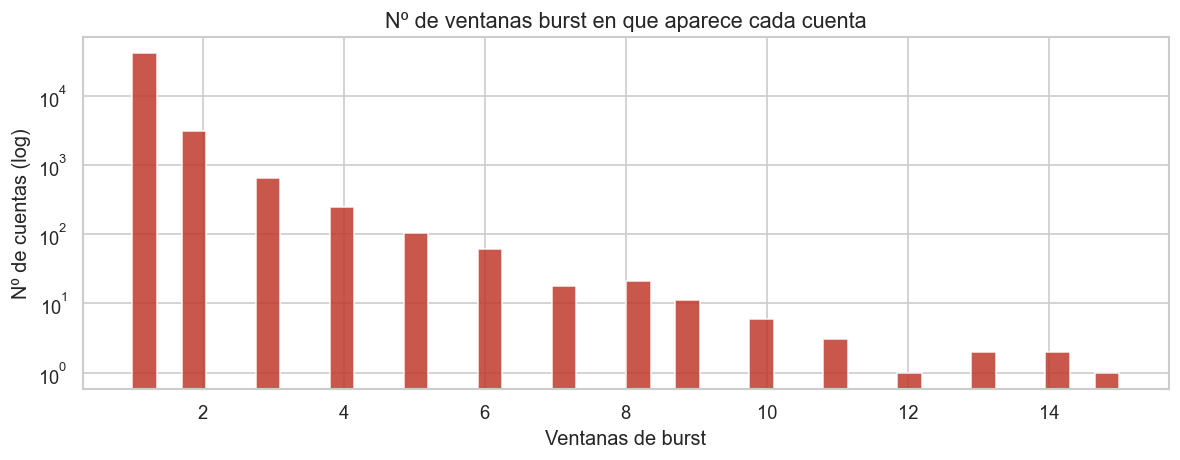

Cuentas en >= 5 ventanas de burst: 227
               user_id  burst_windows_count
 7.042226858621747e+17                   15
           231726084.0                   14
           786625296.0                   14
 8.743729821347594e+17                   13
          2373909360.0                   13
            92356864.0                   12
           152142811.0                   11
           161151263.0                   11
1.0247779165409649e+18                   11
            34639484.0                   10


In [31]:
burst_df = df_sample[df_sample['tweets_in_window'] >= p95]
burst_user_count = burst_df.groupby('user_id')['hour_window'].nunique().reset_index()
burst_user_count.columns = ['user_id', 'burst_windows_count']

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(burst_user_count['burst_windows_count'], bins=40, color='#C0392B', edgecolor='white', alpha=0.85, log=True)
ax.set_title('Nº de ventanas burst en que aparece cada cuenta', fontsize=13)
ax.set_xlabel('Ventanas de burst')
ax.set_ylabel('Nº de cuentas (log)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_cuentas_burst.png')
plt.show()

multi_burst = burst_user_count[burst_user_count['burst_windows_count'] >= 5]
print(f'Cuentas en >= 5 ventanas de burst: {len(multi_burst):,}')
print(burst_user_count.sort_values('burst_windows_count', ascending=False).head(10).to_string(index=False))


### 12.2 Correlación entre variables numéricas

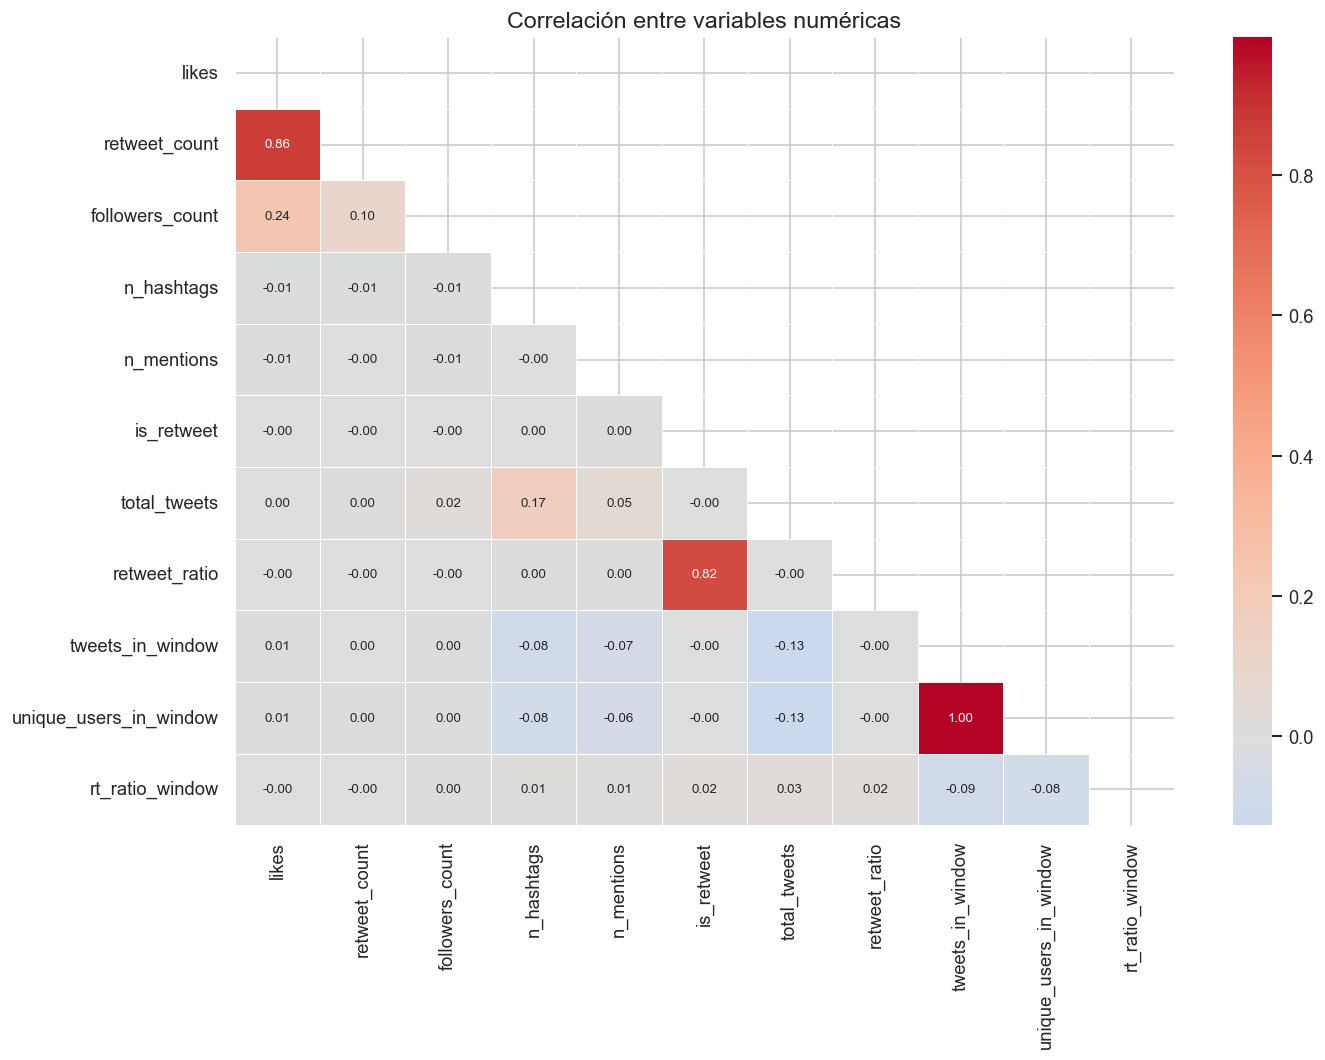

In [32]:
corr_cols = [c for c in [
    'likes', 'retweet_count', 'followers_count', 'n_hashtags',
    'n_mentions', 'is_retweet', 'total_tweets', 'retweet_ratio',
    'tweets_in_window', 'unique_users_in_window', 'rt_ratio_window',
] if c in df_sample.columns]

corr = df_sample[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Correlación entre variables numéricas', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_correlacion.png')
plt.show()


### 12.3 Actividad de las top 10 cuentas por volumen

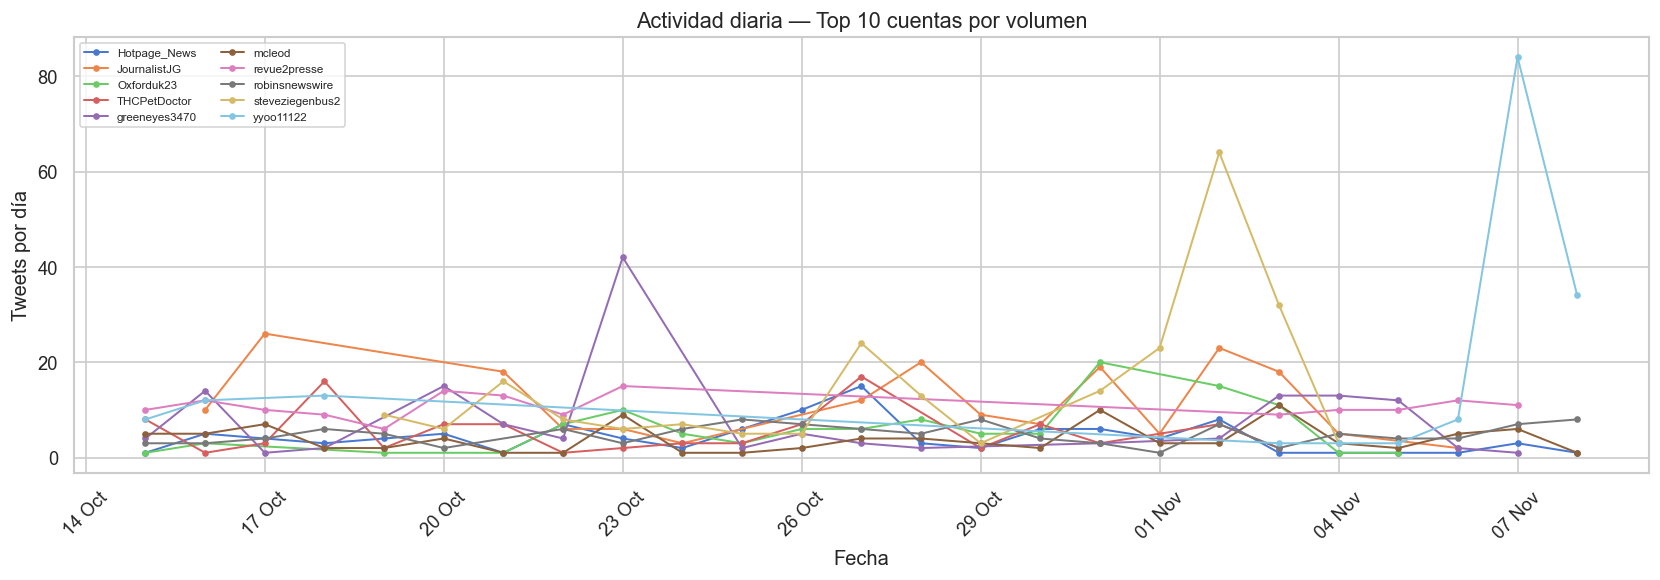

In [33]:
top_users  = df_sample.groupby('user_id').size().nlargest(10).index
top_df     = df_sample[df_sample['user_id'].isin(top_users)].copy()
top_df['user_label'] = top_df['user_screen_name'].fillna(top_df['user_id'].astype(str))

activity         = top_df.groupby(['user_label', 'date']).size().reset_index(name='tweets')
activity['date'] = pd.to_datetime(activity['date'])

fig, ax = plt.subplots(figsize=(14, 5))
for user in activity['user_label'].unique():
    d = activity[activity['user_label'] == user]
    ax.plot(d['date'], d['tweets'], marker='o', markersize=3, linewidth=1.2, label=str(user))

ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=45)
ax.set_title('Actividad diaria — Top 10 cuentas por volumen', fontsize=13)
ax.set_xlabel('Fecha')
ax.set_ylabel('Tweets por día')
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_top_cuentas_actividad.png')
plt.show()


---
## Pendientes
- [ ] Completar tabla de hallazgos con observaciones reales
- [ ] Integrar `bot_detection_data.csv` en A6
- [ ] Definir umbral definitivo de burst (P95 vs P99)
- [ ] Pasar `burst_windows` y `multi_burst` como insumo a A5


## A5. Pipeline de clustering

### A5.0 Configuración

In [34]:
class Config:
    EMBEDDING_MODEL      = 'all-MiniLM-L6-v2'
    EMBEDDING_BATCH_SIZE = 64
    CACHE_DIR            = Path('./embedding_cache')
    CACHE_DIR.mkdir(exist_ok=True)

    SAMPLE_SIZE_SIMILARITY   = 200_000
    SAMPLE_SIZE_EVALUATION   = 200_000
    SAMPLE_SIZE_VISUALIZATION = 200_000
    MAX_ROWS_AGGLOMERATIVE   = 200_000

    KMEANS_N_CLUSTERS  = None   # None → auto-determinado con gap statistic
    KMEANS_RANDOM_STATE = 42
    KMEANS_N_INIT       = 10

    HDBSCAN_MIN_CLUSTER_SIZE   = 5
    HDBSCAN_METRIC             = 'euclidean'
    HDBSCAN_APPROX_MIN_SPAN    = True
    HDBSCAN_CORE_DIST_N_JOBS   = -1
    # Para n > FAST_HDBSCAN_SAMPLE_SIZE se usa subset + KNN en lugar de HDBSCAN completo
    FAST_HDBSCAN_SAMPLE_SIZE   = 10_000
    FAST_HDBSCAN_USE_SAMPLING  = True

    USE_FAISS         = faiss is not None
    SIMILARITY_TOP_K  = 20

    USE_UMAP       = umap is not None   # fallback a t-SNE si no está instalado
    UMAP_N_NEIGHBORS = 15
    UMAP_MIN_DIST    = 0.1


### A5.1 Embeddings (con caché)

In [35]:
def get_embeddings(
    df: pd.DataFrame,
    text_column: str = 'text_clean',
    model_name: str = Config.EMBEDDING_MODEL,
    force_recompute: bool = False,
) -> np.ndarray:
    """Genera o carga embeddings cacheados para la columna de texto indicada."""
    texts        = df[text_column].astype(str).tolist()
    sample_str   = ''.join(texts[:10])
    content_hash = hashlib.md5((sample_str + str(len(texts)) + model_name).encode()).hexdigest()
    cache_file   = Config.CACHE_DIR / f'embeddings_{content_hash}.npy'

    if cache_file.exists() and not force_recompute:
        embeddings = np.load(cache_file)
        if len(embeddings) == len(df):
            logger.info(f'Embeddings cargados desde caché: {cache_file}')
            return embeddings
        logger.warning('Tamaño de caché no coincide; regenerando.')

    logger.info(f'Generando embeddings para {len(texts):,} textos...')
    model      = SentenceTransformer(model_name)
    embeddings = model.encode(texts, batch_size=Config.EMBEDDING_BATCH_SIZE,
                              show_progress_bar=True, convert_to_numpy=True)
    np.save(cache_file, embeddings)
    return embeddings


### A5.2 Pares de similitud

In [36]:
def _faiss_similarity_pairs(
    emb_norm: np.ndarray,
    indices: np.ndarray,
    top_k: int,
    threshold: Optional[float],
) -> List[Tuple[int, int, float]]:
    n, d  = emb_norm.shape
    nlist = min(100, int(np.sqrt(n)))

    if n < 1000:
        index = faiss.IndexFlatIP(d)
    else:
        quantizer = faiss.IndexFlatIP(d)
        index     = faiss.IndexIVFFlat(quantizer, d, nlist)
        index.train(emb_norm)
    index.add(emb_norm)

    k_search            = min(top_k * 2, n - 1)
    similarities, nbrs  = index.search(emb_norm, k_search + 1)

    unique_pairs: Dict[Tuple[int, int], float] = {}
    for i in range(n):
        for j_idx in range(1, k_search + 1):
            j   = nbrs[i, j_idx]
            sim = similarities[i, j_idx]
            if i < j and (threshold is None or sim >= threshold):
                key = (i, j)
                if key not in unique_pairs or sim > unique_pairs[key]:
                    unique_pairs[key] = sim

    pairs = [(indices[i], indices[j], s) for (i, j), s in unique_pairs.items()]
    pairs.sort(key=lambda x: x[2], reverse=True)
    return pairs[:top_k] if top_k else pairs


def _sklearn_similarity_pairs(
    emb_norm: np.ndarray,
    indices: np.ndarray,
    top_k: int,
    threshold: Optional[float],
) -> List[Tuple[int, int, float]]:
    if len(emb_norm) > 10_000:
        logger.warning('Vecinos exactos sobre muestra grande; puede ser lento.')
    nn = NearestNeighbors(metric='cosine', algorithm='brute')
    nn.fit(emb_norm)
    k_search          = min(top_k * 2, len(emb_norm) - 1)
    distances, nbrs   = nn.kneighbors(emb_norm, n_neighbors=k_search + 1)

    unique_pairs: Dict[Tuple[int, int], float] = {}
    for i in range(len(emb_norm)):
        for j_idx in range(1, k_search + 1):
            j   = nbrs[i, j_idx]
            sim = 1 - distances[i, j_idx]
            if i < j and (threshold is None or sim >= threshold):
                key = (i, j)
                if key not in unique_pairs or sim > unique_pairs[key]:
                    unique_pairs[key] = sim

    pairs = [(indices[i], indices[j], s) for (i, j), s in unique_pairs.items()]
    pairs.sort(key=lambda x: x[2], reverse=True)
    return pairs[:top_k] if top_k else pairs


def generate_similarity_pairs(
    embeddings: np.ndarray,
    top_k: int = Config.SIMILARITY_TOP_K,
    threshold: Optional[float] = None,
    sample_size: Optional[int] = None,
) -> List[Tuple[int, int, float]]:
    """Genera pares de similitud coseno usando FAISS (si disponible) o sklearn."""
    n = len(embeddings)
    if sample_size and n > sample_size:
        logger.info(f'Usando muestra de {sample_size:,} para similitud (total {n:,})')
        idx      = np.random.choice(n, size=sample_size, replace=False)
        emb_norm = normalize(embeddings[idx], norm='l2')
        indices  = idx
    else:
        emb_norm = normalize(embeddings, norm='l2')
        indices  = np.arange(n)

    if Config.USE_FAISS and faiss is not None:
        return _faiss_similarity_pairs(emb_norm, indices, top_k, threshold)
    return _sklearn_similarity_pairs(emb_norm, indices, top_k, threshold)


### A5.3 Determinación automática de clusters

In [37]:
def gap_statistic(
    embeddings: np.ndarray,
    max_clusters: int = 15,
    n_refs: int = 5,
    sample_size: int = 5_000,
) -> int:
    """Gap statistic (Tibshirani et al., 2001) para estimar el número óptimo de clusters."""
    n = len(embeddings)
    if n <= 2:
        return 1

    emb = embeddings[np.random.choice(n, size=min(n, sample_size), replace=False)]
    max_clusters = min(max_clusters, len(emb) - 1)
    if max_clusters < 2:
        return 1

    K        = range(1, max_clusters + 1)
    inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(emb).inertia_ for k in K]

    ref_inertias = []
    lo, hi = emb.min(axis=0), emb.max(axis=0)
    for _ in range(n_refs):
        ref = np.random.uniform(lo, hi, size=emb.shape)
        ref_inertias.append([KMeans(n_clusters=k, random_state=42, n_init=10).fit(ref).inertia_ for k in K])

    gap = np.log(ref_inertias).mean(axis=0) - np.log(inertias)
    return int(np.argmax(gap)) + 1


def auto_determine_clusters(
    embeddings: np.ndarray,
    method: str = 'gap',
    max_clusters: int = 15,
) -> int:
    """Determina k óptimo vía gap statistic o silhouette. Retorna un valor en [2, max_clusters]."""
    n = len(embeddings)
    if n <= 2:
        return 1
    max_clusters = min(max_clusters, n - 1)
    if max_clusters < 2:
        return 1

    if method == 'gap':
        return max(2, min(gap_statistic(embeddings, max_clusters), max_clusters))

    if method == 'silhouette':
        sample = embeddings if n <= Config.SAMPLE_SIZE_EVALUATION else (
            embeddings[np.random.choice(n, Config.SAMPLE_SIZE_EVALUATION, replace=False)]
        )
        best_k, best_score = 2, -1.0
        for k in range(2, min(max_clusters, len(sample) - 1) + 1):
            labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(sample)
            if len(set(labels)) > 1:
                score = silhouette_score(sample, labels, metric='cosine')
                if score > best_score:
                    best_score, best_k = score, k
        return best_k

    raise ValueError("method debe ser 'gap' o 'silhouette'")


### A5.4 Clustering

In [38]:
def _fast_hdbscan(
    embeddings: np.ndarray,
    min_cluster_size: int,
    **kwargs,
) -> np.ndarray:
    """
    HDBSCAN sobre un subconjunto aleatorio + KNN para clasificar el resto.
    Usado automáticamente cuando n > Config.FAST_HDBSCAN_SAMPLE_SIZE.
    """
    n          = len(embeddings)
    sample_n   = Config.FAST_HDBSCAN_SAMPLE_SIZE
    idx        = np.random.choice(n, size=sample_n, replace=False)
    sample_emb = embeddings[idx]

    clusterer     = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size,
                                    approx_min_span_tree=Config.HDBSCAN_APPROX_MIN_SPAN,
                                    gen_min_span_tree=False,
                                    core_dist_n_jobs=Config.HDBSCAN_CORE_DIST_N_JOBS, **kwargs)
    sample_labels = clusterer.fit_predict(sample_emb)

    non_noise = sample_labels != -1
    if not non_noise.any():
        logger.warning('Todos los puntos del subconjunto son ruido.')
        return np.full(n, -1)

    knn = KNeighborsClassifier(n_neighbors=5, metric='cosine')
    knn.fit(sample_emb[non_noise], sample_labels[non_noise])

    rest_mask   = ~np.isin(np.arange(n), idx)
    full_labels = np.full(n, -1)
    full_labels[idx]        = sample_labels
    full_labels[rest_mask]  = knn.predict(embeddings[rest_mask])

    n_clusters = len(set(full_labels)) - (1 if -1 in full_labels else 0)
    logger.info(f'Fast HDBSCAN: {n_clusters} clusters, {(full_labels == -1).sum()} ruido')
    return full_labels


def apply_clustering(
    df: pd.DataFrame,
    embeddings: np.ndarray,
    methods: List[str] = ('kmeans', 'hdbscan', 'agglomerative'),
    kmeans_params: Optional[Dict] = None,
    hdbscan_params: Optional[Dict] = None,
    agglomerative_params: Optional[Dict] = None,
    auto_determine: bool = True,
    use_fast_hdbscan: Optional[bool] = None,
) -> pd.DataFrame:
    """Aplica uno o más métodos de clustering y añade columnas cluster_* al DataFrame."""
    n  = len(df)
    df = df.copy()

    if 'kmeans' in methods:
        p      = kmeans_params or {}
        k      = p.get('n_clusters') or (auto_determine_clusters(embeddings) if auto_determine else 5)
        k      = min(k, n - 1)
        km     = KMeans(n_clusters=k, random_state=p.get('random_state', Config.KMEANS_RANDOM_STATE),
                        n_init=p.get('n_init', Config.KMEANS_N_INIT), max_iter=p.get('max_iter', 300))
        df['cluster_kmeans'] = km.fit_predict(embeddings)
        logger.info(f'KMeans: {k} clusters')

    if 'hdbscan' in methods:
        if hdbscan is None:
            logger.warning('hdbscan no instalado; omitiendo.')
        else:
            p                = hdbscan_params or {}
            min_cluster_size = p.get('min_cluster_size', Config.HDBSCAN_MIN_CLUSTER_SIZE)
            use_fast         = (Config.FAST_HDBSCAN_USE_SAMPLING and n > Config.FAST_HDBSCAN_SAMPLE_SIZE
                                if use_fast_hdbscan is None else use_fast_hdbscan)
            extra            = {k: v for k, v in p.items() if k not in ('min_cluster_size', 'metric')}

            if use_fast:
                labels = _fast_hdbscan(embeddings, min_cluster_size, **extra)
            else:
                clusterer = hdbscan.HDBSCAN(
                    min_cluster_size=min_cluster_size,
                    min_samples=p.get('min_samples'),
                    metric=p.get('metric', Config.HDBSCAN_METRIC),
                    cluster_selection_method=p.get('cluster_selection_method', 'eom'),
                    prediction_data=p.get('prediction_data', True),
                    approx_min_span_tree=p.get('approx_min_span_tree', Config.HDBSCAN_APPROX_MIN_SPAN),
                    gen_min_span_tree=False,
                    core_dist_n_jobs=p.get('core_dist_n_jobs', Config.HDBSCAN_CORE_DIST_N_JOBS),
                )
                labels = clusterer.fit_predict(embeddings)

            df['cluster_hdbscan'] = labels
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            logger.info(f'HDBSCAN: {n_clusters} clusters, {(labels == -1).sum()} ruido')

    if 'agglomerative' in methods:
        if n > Config.MAX_ROWS_AGGLOMERATIVE:
            logger.warning(f'Agglomerative omitido (n={n:,} > {Config.MAX_ROWS_AGGLOMERATIVE:,})')
        else:
            p   = agglomerative_params or {}
            k   = p.get('n_clusters') or (auto_determine_clusters(embeddings) if auto_determine else 5)
            k   = min(k, n - 1)
            agg = AgglomerativeClustering(n_clusters=k,
                                          linkage=p.get('linkage', 'ward'),
                                          metric=p.get('metric', 'euclidean'))
            df['cluster_agglomerative'] = agg.fit_predict(embeddings)
            logger.info(f'Agglomerative: {k} clusters')

    return df


### A5.5 Evaluación

In [39]:
def evaluate_clustering(
    embeddings: np.ndarray,
    labels: np.ndarray,
    sample_size: int = Config.SAMPLE_SIZE_EVALUATION,
) -> Dict[str, float]:
    """Calcula silhouette, Davies-Bouldin y Calinski-Harabasz sobre una muestra."""
    n = len(embeddings)
    if n > sample_size:
        idx    = np.random.choice(n, size=sample_size, replace=False)
        emb, l = embeddings[idx], labels[idx]
    else:
        emb, l = embeddings, labels

    mask = l != -1
    if not mask.any() or len(set(l[mask])) < 2:
        return {'silhouette': -1.0, 'davies_bouldin': -1.0, 'calinski_harabasz': -1.0}

    emb_c, l_c = emb[mask], l[mask]
    results     = {}
    for name, fn in [
        ('silhouette',        lambda: silhouette_score(emb_c, l_c, metric='cosine')),
        ('davies_bouldin',    lambda: davies_bouldin_score(emb_c, l_c)),
        ('calinski_harabasz', lambda: calinski_harabasz_score(emb_c, l_c)),
    ]:
        try:
            results[name] = fn()
        except Exception:
            results[name] = -1.0
    return results


### A5.6 Visualización

In [40]:
def _reduce_dimensions(embeddings: np.ndarray) -> np.ndarray:
    """Reduce a 2D con UMAP si está disponible, sino t-SNE."""
    if Config.USE_UMAP and umap is not None:
        return umap.UMAP(n_neighbors=Config.UMAP_N_NEIGHBORS,
                         min_dist=Config.UMAP_MIN_DIST, random_state=42).fit_transform(embeddings)
    return TSNE(n_components=2, random_state=42, perplexity=min(30, len(embeddings) - 1),
                max_iter=1000, learning_rate='auto', init='pca').fit_transform(embeddings)


def visualize_clusters(
    df: pd.DataFrame,
    embeddings: np.ndarray,
    methods_to_plot: List[str] = ('kmeans', 'hdbscan'),
    figsize: Tuple[int, int] = (15, 8),
) -> plt.Figure:
    """Proyección 2D (UMAP/t-SNE) de los clusters con métricas de evaluación."""
    n = len(df)
    if n > Config.SAMPLE_SIZE_VISUALIZATION:
        idx       = np.random.choice(n, size=Config.SAMPLE_SIZE_VISUALIZATION, replace=False)
        emb_plot  = embeddings[idx]
        df_plot   = df.iloc[idx].copy()
    else:
        emb_plot, df_plot = embeddings, df

    logger.info('Reduciendo dimensiones...')
    coords = _reduce_dimensions(emb_plot)
    axis_label = ('UMAP-1', 'UMAP-2') if Config.USE_UMAP else ('t-SNE-1', 't-SNE-2')

    n_methods  = len(methods_to_plot)
    fig, axes  = plt.subplots(1, n_methods, figsize=(figsize[0] * n_methods, figsize[1]))
    if n_methods == 1:
        axes = [axes]

    for ax, method in zip(axes, methods_to_plot):
        col = f'cluster_{method}'
        if col not in df_plot.columns:
            logger.warning(f'Columna {col} no encontrada; omitiendo.')
            continue

        labels          = df_plot[col].values
        unique_clusters = sorted(set(labels))
        valid_clusters  = [c for c in unique_clusters if c != -1]
        palette         = sns.color_palette('tab10', len(valid_clusters))

        for i, cluster_id in enumerate(valid_clusters):
            mask = labels == cluster_id
            ax.scatter(coords[mask, 0], coords[mask, 1], c=[palette[i % len(palette)]],
                       label=f'Cluster {cluster_id}', alpha=0.7, s=30,
                       edgecolors='black', linewidth=0.5)

        if method == 'hdbscan' and -1 in unique_clusters:
            noise = labels == -1
            ax.scatter(coords[noise, 0], coords[noise, 1], c='lightgray',
                       label='Ruido', alpha=0.5, s=20, marker='x')

        metrics  = evaluate_clustering(embeddings, df[col].values)
        textstr  = (f"Silhouette: {metrics['silhouette']:.3f}\n"
                    f"DB: {metrics['davies_bouldin']:.3f}\n"
                    f"CH: {metrics['calinski_harabasz']:.1f}")
        ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

        ax.set_title(f'{method.upper()} Clustering', fontsize=14, fontweight='bold')
        ax.set_xlabel(axis_label[0])
        ax.set_ylabel(axis_label[1])
        ax.grid(True, alpha=0.3)
        ax.set_facecolor('#f8f9fa')
        logger.info(f'{method}: {metrics}')

    plt.tight_layout()
    plt.show()
    return fig


### A5.7 Pipeline completo

2026-06-24 21:34:37,276 - INFO - Generando embeddings para 20,000 textos...
2026-06-24 21:34:37,283 - INFO - No device provided, using cpu
2026-06-24 21:34:37,818 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
2026-06-24 21:34:37,819 - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-06-24 21:34:37,829 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/modules.json "HTTP/1.1 200 OK"
2026-06-24 21:34:38,024 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
2026-06-24 21:34:38,031 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentenc

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

2026-06-24 21:34:39,563 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
2026-06-24 21:34:39,731 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
2026-06-24 21:34:39,911 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
2026-06-24 21:34:40,073 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
2026-06-24 21:34:40,229 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-06-24 21:34:40,237 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/senten

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

2026-06-24 21:35:54,765 - INFO - 20 pares generados
2026-06-24 21:38:14,927 - INFO - KMeans: 15 clusters
2026-06-24 21:39:12,964 - INFO - Fast HDBSCAN: 44 clusters, 8280 ruido
2026-06-24 21:39:12,968 - INFO - HDBSCAN: 44 clusters, 8280 ruido
2026-06-24 21:39:12,969 - INFO - Reduciendo dimensiones...
2026-06-24 21:39:53,700 - INFO - kmeans: {'silhouette': 0.12434551119804382, 'davies_bouldin': 4.474720990332335, 'calinski_harabasz': 413.90574278008904}
2026-06-24 21:39:55,188 - INFO - hdbscan: {'silhouette': -0.07092121988534927, 'davies_bouldin': 4.31486571099038, 'calinski_harabasz': 104.65012293055503}


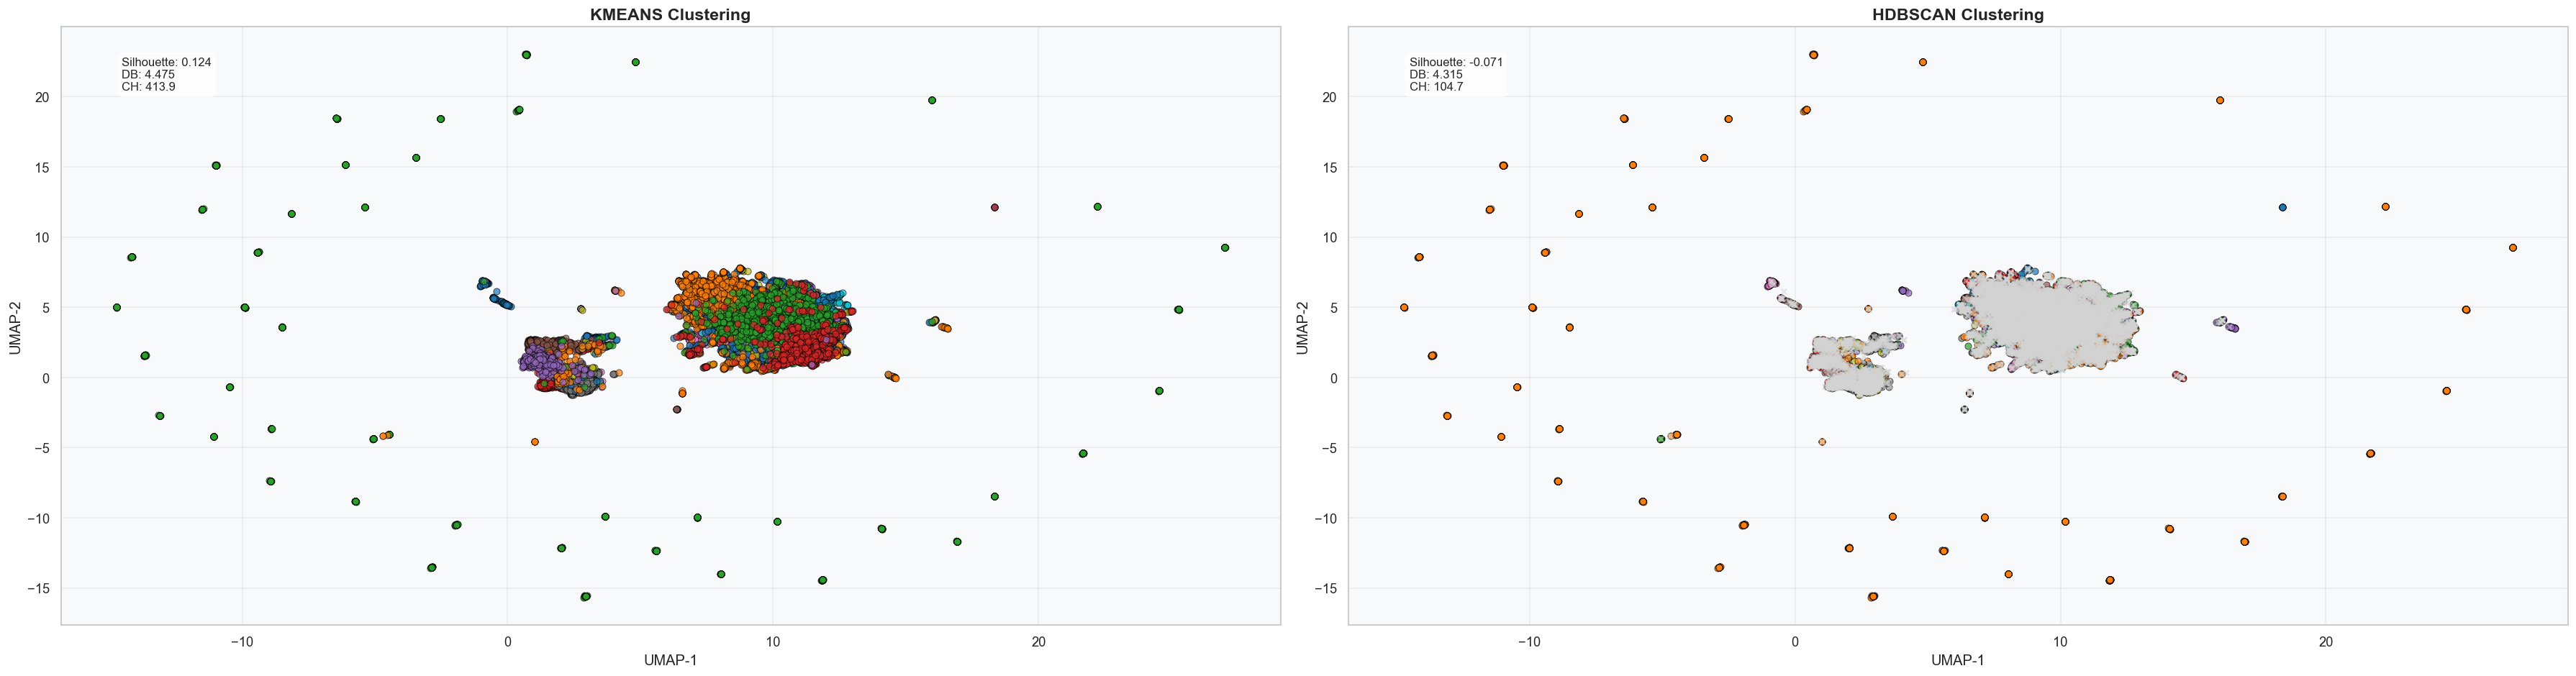

In [41]:
def run_clustering_pipeline(
    df: pd.DataFrame,
    text_column: str = 'text_clean',
    methods: List[str] = ('kmeans', 'hdbscan', 'agglomerative'),
    compute_similarity: bool = True,
) -> Tuple[pd.DataFrame, List[Tuple[int, int, float]], np.ndarray]:
    """Pipeline completo: embeddings → similitud → clustering → visualización."""
    embeddings = get_embeddings(df, text_column)

    pairs: List[Tuple[int, int, float]] = []
    if compute_similarity:
        n     = len(df)
        pairs = generate_similarity_pairs(
            embeddings,
            sample_size=Config.SAMPLE_SIZE_SIMILARITY if n > Config.SAMPLE_SIZE_SIMILARITY else None,
        )
        logger.info(f'{len(pairs)} pares generados')

    df_clustered = apply_clustering(df, embeddings, list(methods))
    visualize_clusters(df_clustered, embeddings, methods_to_plot=list(methods))
    return df_clustered, pairs, embeddings


CLUSTER_N  = 20_000
trump_cl   = df[df['candidate'] == 'trump'].sample(min(len(df[df['candidate'] == 'trump']), CLUSTER_N // 2), random_state=42)
biden_cl   = df[df['candidate'] == 'biden'].sample(min(len(df[df['candidate'] == 'biden']), CLUSTER_N // 2), random_state=42)
df_cluster = pd.concat([trump_cl, biden_cl]).reset_index(drop=True)

df_result, similarity_pairs, embeddings = run_clustering_pipeline(
    df_cluster,
    methods=['kmeans', 'hdbscan'],
    compute_similarity=True,
)


### A5.8 Análisis temporal de clusters

In [42]:
def analyze_cluster_times(
    df: pd.DataFrame,
    cluster_cols: Union[str, List[str]],
    time_col: str = 'created_at',
    time_unit: str = 'seconds',
    compute_pairwise: bool = True,
    max_pairwise_size: int = 5_000,
    filter_span_seconds: Optional[float] = None,
) -> pd.DataFrame:
    """Estadísticas de dispersión temporal para cada cluster."""
    if not pd.api.types.is_datetime64_any_dtype(df[time_col]):
        df = df.copy()
        df[time_col] = pd.to_datetime(df[time_col])

    df_clean = df[df[time_col].notna()].copy()
    if df_clean.empty:
        return pd.DataFrame()

    # int64 en nanosegundos → dividir a milisegundos para trabajar con escala razonable
    times_ms  = df_clean[time_col].astype('int64') // 10 ** 6
    factors   = {'seconds': 1_000, 'minutes': 60_000, 'hours': 3_600_000, 'days': 86_400_000}
    factor    = factors.get(time_unit, 1_000)

    if isinstance(cluster_cols, str):
        cluster_cols = [cluster_cols]

    rows = []
    for col in cluster_cols:
        if col not in df_clean.columns:
            continue
        for cluster_id, group in df_clean.groupby(col):
            t = times_ms.loc[group.index].values
            n = len(t)
            if n == 0:
                continue
            span         = t.max() - t.min()
            mean_pairwise = np.nan
            if compute_pairwise and 1 < n <= max_pairwise_size:
                diff          = np.abs(t[:, None] - t[None, :])
                mean_pairwise = diff[np.triu_indices(n, k=1)].mean()
            rows.append({
                'cluster_method':     col,
                'cluster_id':         cluster_id,
                'count':              n,
                'mean_time':          t.mean()   / factor,
                'std_time':           t.std(ddof=1) / factor if n > 1 else 0.0,
                'span':               span       / factor,
                'mean_pairwise_diff': mean_pairwise / factor if not np.isnan(mean_pairwise) else np.nan,
            })

    result = pd.DataFrame(rows)
    if filter_span_seconds is not None:
        result = result[result['span'] <= filter_span_seconds / (factor / 1_000)]
    return result


def get_cluster_rows(
    df: pd.DataFrame,
    cluster_col: str,
    cluster_id: Union[int, List[int], 'np.integer'],
) -> pd.DataFrame:
    """Devuelve las filas del DataFrame que pertenecen a los clusters indicados."""
    if isinstance(cluster_id, (int, np.integer)):
        cluster_id = [int(cluster_id)]
    elif isinstance(cluster_id, list):
        cluster_id = [int(c) for c in cluster_id]
    else:
        raise TypeError(f'cluster_id debe ser int, list o numpy integer, recibido: {type(cluster_id)}')
    return df[df[cluster_col].isin(cluster_id)]


### A5.9 Ventanas temporalmente próximas

In [43]:
def get_temporally_close_rows(
    df: pd.DataFrame,
    time_col: str = 'created_at',
    delta_seconds: float = 5.0,
    min_rows_per_window: int = 2,
    return_original_indices: bool = True,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Agrupa filas en ventanas de burst por proximidad temporal (cadena de gaps consecutivos).
    Retorna (filas en ventanas válidas, estadísticas por ventana).
    """
    df = df.copy()
    if not pd.api.types.is_datetime64_any_dtype(df[time_col]):
        df[time_col] = pd.to_datetime(df[time_col], errors='coerce')

    df = df[df[time_col].notna()].copy()
    if df.empty:
        return pd.DataFrame(), pd.DataFrame()

    df_sorted = df.sort_values(time_col)
    diffs     = df_sorted[time_col].diff().dt.total_seconds().fillna(0)

    df_sorted['time_window_id'] = (diffs > delta_seconds).cumsum()
    window_sizes  = df_sorted.groupby('time_window_id').size()
    valid_windows = window_sizes[window_sizes >= min_rows_per_window].index

    windows_df = df_sorted[df_sorted['time_window_id'].isin(valid_windows)].copy()
    if return_original_indices:
        windows_df['original_index'] = windows_df.index

    stats = (
        windows_df.groupby('time_window_id')
        .agg(start=(time_col, 'min'), end=(time_col, 'max'), count=(time_col, 'size'))
        .reset_index()
    )
    stats['duration_sec'] = (stats['end'] - stats['start']).dt.total_seconds()

    return windows_df.reset_index(drop=True), stats


### A5.10 Análisis temporal-semántico combinado

In [44]:
def analyze_temporal_semantic_windows(
    df: pd.DataFrame,
    windows_df: pd.DataFrame,
    cluster_col: str = 'cluster_hdbscan',
    embedding_col: str = 'embeddings',
    min_cluster_purity: float = 0.5,
    min_avg_similarity: Optional[float] = None,
    max_window_size_for_pairwise: int = 5_000,
    verbose: bool = True,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Para cada ventana temporal, calcula pureza de cluster dominante y similitud coseno promedio.
    Filtra ventanas según min_cluster_purity y min_avg_similarity.
    """
    if windows_df.empty or 'original_index' not in windows_df.columns:
        raise ValueError("windows_df vacío o sin columna 'original_index'.")
    if embedding_col not in df.columns:
        raise ValueError(f"Columna '{embedding_col}' no encontrada en df.")

    all_embeddings = np.array(df[embedding_col].tolist())
    summaries      = []
    kept_ids       = []

    for window_id, group in windows_df.groupby('time_window_id'):
        orig_idx = group['original_index'].values
        count    = len(orig_idx)

        cluster_labels = df.loc[orig_idx, cluster_col].values
        unique, counts = np.unique(cluster_labels, return_counts=True)
        if not len(unique):
            continue

        dominant = unique[np.argmax(counts)]
        purity   = counts.max() / count

        avg_sim = std_sim = np.nan
        if count > 1:
            if count <= max_window_size_for_pairwise:
                sim_mat   = cosine_similarity(all_embeddings[orig_idx])
                upper     = sim_mat[np.triu_indices_from(sim_mat, k=1)]
                avg_sim   = upper.mean()
                std_sim   = upper.std()
            elif verbose:
                logger.warning(f'Ventana {window_id}: {count} filas superan el límite pairwise.')

        summaries.append({
            'time_window_id':   window_id,
            'count':            count,
            'dominant_cluster': dominant,
            'cluster_purity':   purity,
            'avg_pairwise_sim': avg_sim,
            'std_pairwise_sim': std_sim,
        })

        keep = purity >= min_cluster_purity
        if min_avg_similarity is not None:
            keep = keep and not np.isnan(avg_sim) and avg_sim >= min_avg_similarity
        if keep:
            kept_ids.append(window_id)

    if verbose:
        logger.info(f'Ventanas conservadas: {len(kept_ids)} / {len(summaries)}')

    filtered = windows_df[windows_df['time_window_id'].isin(kept_ids)].copy()
    return filtered, pd.DataFrame(summaries)


def get_rows_for_window(
    df: pd.DataFrame,
    windows_df: pd.DataFrame,
    window_id: int,
    text_col: str = 'text_clean',
) -> pd.DataFrame:
    """Devuelve las filas de df que pertenecen a la ventana indicada."""
    rows = windows_df[windows_df['time_window_id'] == window_id]
    if rows.empty:
        return pd.DataFrame()
    return df.loc[rows['original_index'].values,
                  [text_col, 'created_at', 'cluster_kmeans', 'cluster_hdbscan']].copy()


## A6. Clasificación supervisada

### A6.1 Carga y enriquecimiento

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score,
    PrecisionRecallDisplay, RocCurveDisplay,
)
from xgboost import XGBClassifier

df_a6 = pd.read_csv(OUTPUT_DIR / 'df_processed_sample.csv', low_memory=False)
df_a6['created_at']  = pd.to_datetime(df_a6['created_at'],  utc=True, errors='coerce')
df_a6['hour_window'] = pd.to_datetime(df_a6['hour_window'], utc=True, errors='coerce')

for col in ['hashtags', 'mentions']:
    if col in df_a6.columns:
        df_a6[col] = df_a6[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])

cluster_map             = df_result[['tweet_id', 'cluster_hdbscan']].drop_duplicates()
df_a6['tweet_id']       = df_a6['tweet_id'].astype(str)
cluster_map['tweet_id'] = cluster_map['tweet_id'].astype(str)
df_a6 = df_a6.merge(cluster_map, on='tweet_id', how='left')
df_a6['cluster_hdbscan'] = df_a6['cluster_hdbscan'].fillna(-1).astype(int)

print(f'Dataset cargado: {len(df_a6):,} tweets')
print(df_a6['cluster_hdbscan'].value_counts().sort_index())


Dataset cargado: 200,000 tweets
cluster_hdbscan
-1     188280
 0         15
 1         63
 2         88
 3        114
 4         47
 5        223
 6        156
 7        183
 8        298
 9        155
 10       415
 11      1550
 12        31
 13        64
 14        66
 15       174
 16       276
 17       205
 18       200
 19       176
 20       138
 21       383
 22       852
 23        53
 24       316
 25       120
 26       135
 27       669
 28       182
 29       111
 30        49
 31        92
 32       152
 33       427
 34       158
 35       217
 36       675
 37       370
 38       285
 39       148
 40       129
 41      1160
 42       325
 43        75
Name: count, dtype: int64


### A6.2 Etiquetado heurístico

Orgánico (0):   196,807 (98.4%)
Sospechoso (1): 3,193 (1.6%)


2026-06-24 21:40:21,827 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-24 21:40:21,828 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


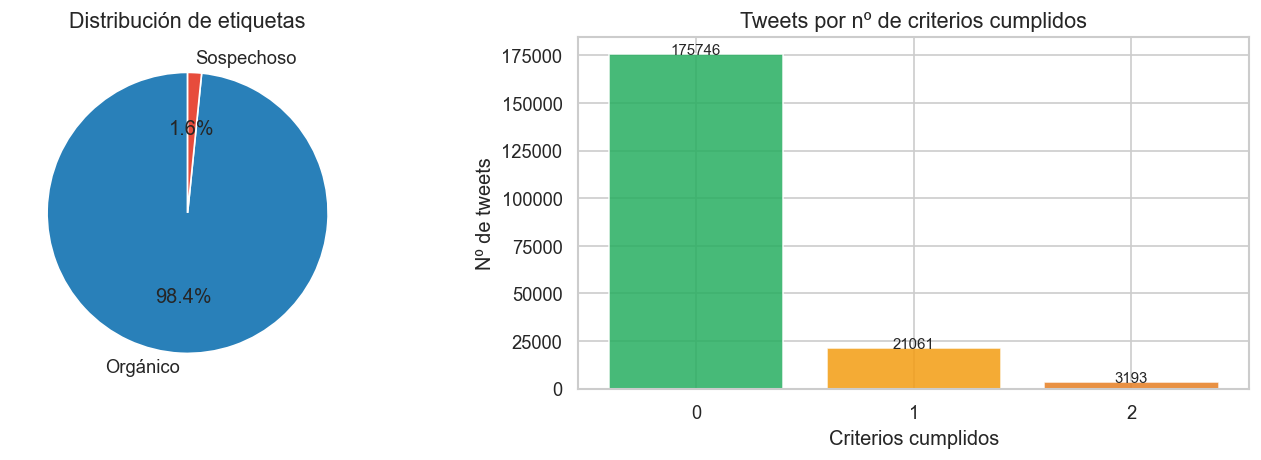

In [46]:
# Criterio 1: pertenencia al cluster más denso de HDBSCAN
# Criterio 2: actividad en ventanas de burst (P95)
# Criterio 3: similitud textual >= 0.8 con otro tweet de la misma ventana horaria
# Un tweet se marca como sospechoso si cumple al menos 2 de los 3 criterios

df_a6['crit_cluster'] = (df_a6['cluster_hdbscan'] == 1).astype(int)

p95_a6              = df_a6['tweets_in_window'].quantile(0.95)
df_a6['crit_burst'] = (df_a6['tweets_in_window'] >= p95_a6).astype(int)

tfidf_a6     = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=3, sublinear_tf=True)
tfidf_mat_a6 = tfidf_a6.fit_transform(df_a6['text_clean'].fillna(''))
SIM_THRESHOLD = 0.8
high_sim_idx  = set()

for window in df_a6['hour_window'].dropna().unique():
    idx = df_a6[df_a6['hour_window'] == window].index.tolist()
    if len(idx) < 2:
        continue
    sim = cosine_similarity(tfidf_mat_a6[idx])
    np.fill_diagonal(sim, 0)
    for p, q in np.argwhere(sim >= SIM_THRESHOLD):
        high_sim_idx.update([idx[p], idx[q]])

df_a6['crit_similitud'] = 0
df_a6.loc[list(high_sim_idx), 'crit_similitud'] = 1

df_a6['criterios_cumplidos'] = df_a6[['crit_cluster', 'crit_burst', 'crit_similitud']].sum(axis=1)
df_a6['label']               = (df_a6['criterios_cumplidos'] >= 2).astype(int)

print(f'Orgánico (0):   {(df_a6["label"] == 0).sum():,} ({(df_a6["label"] == 0).mean() * 100:.1f}%)')
print(f'Sospechoso (1): {(df_a6["label"] == 1).sum():,} ({(df_a6["label"] == 1).mean() * 100:.1f}%)')
df_a6.to_csv(OUTPUT_DIR / 'df_etiquetado.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df_a6['label'].value_counts()
axes[0].pie(counts, labels=['Orgánico', 'Sospechoso'], autopct='%1.1f%%',
            colors=['#2980B9', '#E74C3C'], startangle=90)
axes[0].set_title('Distribución de etiquetas', fontsize=13)

crit_counts = df_a6['criterios_cumplidos'].value_counts().sort_index()
axes[1].bar(crit_counts.index.astype(str), crit_counts.values,
            color=['#27AE60', '#F39C12', '#E67E22', '#E74C3C'], alpha=0.85)
axes[1].set_title('Tweets por nº de criterios cumplidos', fontsize=13)
axes[1].set_xlabel('Criterios cumplidos')
axes[1].set_ylabel('Nº de tweets')
for i, v in enumerate(crit_counts.values):
    axes[1].text(i, v + 100, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'a6_distribucion_etiquetas.png')
plt.show()


### A6.3 Features y split

In [47]:
FEATURE_COLS = [c for c in [
    'followers_count', 'likes', 'retweet_count',
    'n_hashtags', 'n_mentions', 'is_retweet',
    'hour', 'day_of_week', 'account_age_days',
    'total_tweets', 'retweet_ratio', 'avg_likes',
    'tweets_in_window', 'unique_users_in_window', 'rt_ratio_window',
] if c in df_a6.columns]

X        = df_a6[FEATURE_COLS].fillna(0).values
y        = df_a6['label'].values
X_scaled = MinMaxScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y,
)
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print(f'Sospechosos train: {y_train.sum():,} ({y_train.mean() * 100:.1f}%)')


Train: 160,000 | Test: 40,000
Sospechosos train: 2,554 (1.6%)


### A6.4 Entrenamiento

In [48]:
models = {
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42,
                                                  class_weight='balanced', n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=200, random_state=42, eval_metric='logloss',
                                         scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()),
}
cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    print(f'\nEntrenando {name}...')
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1-score':  round(f1_score(y_test, y_pred, zero_division=0), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_proba), 4),
        'CV F1':     round(cross_val_score(model, X_scaled, y, cv=cv, scoring='f1').mean(), 4),
        'model':     model,
        'y_pred':    y_pred,
        'y_proba':   y_proba,
    }
    for k, v in results[name].items():
        if k not in ('model', 'y_pred', 'y_proba'):
            print(f'  {k}: {v}')



Entrenando Regresión Logística...
  Accuracy: 0.9491
  Precision: 0.2386
  Recall: 0.9984
  F1-score: 0.3851
  ROC-AUC: 0.9712
  CV F1: 0.3907

Entrenando Random Forest...
  Accuracy: 0.9828
  Precision: 0.4031
  Recall: 0.1628
  F1-score: 0.2319
  ROC-AUC: 0.9762
  CV F1: 0.1927

Entrenando XGBoost...
  Accuracy: 0.9605
  Precision: 0.2524
  Recall: 0.7512
  F1-score: 0.3778
  ROC-AUC: 0.9757
  CV F1: 0.3844


### A6.5 Comparación de modelos

                     Accuracy  Precision  Recall  F1-score  ROC-AUC
Regresión Logística    0.9491     0.2386  0.9984    0.3851   0.9712
Random Forest          0.9828     0.4031  0.1628    0.2319   0.9762
XGBoost                0.9605     0.2524  0.7512    0.3778   0.9757


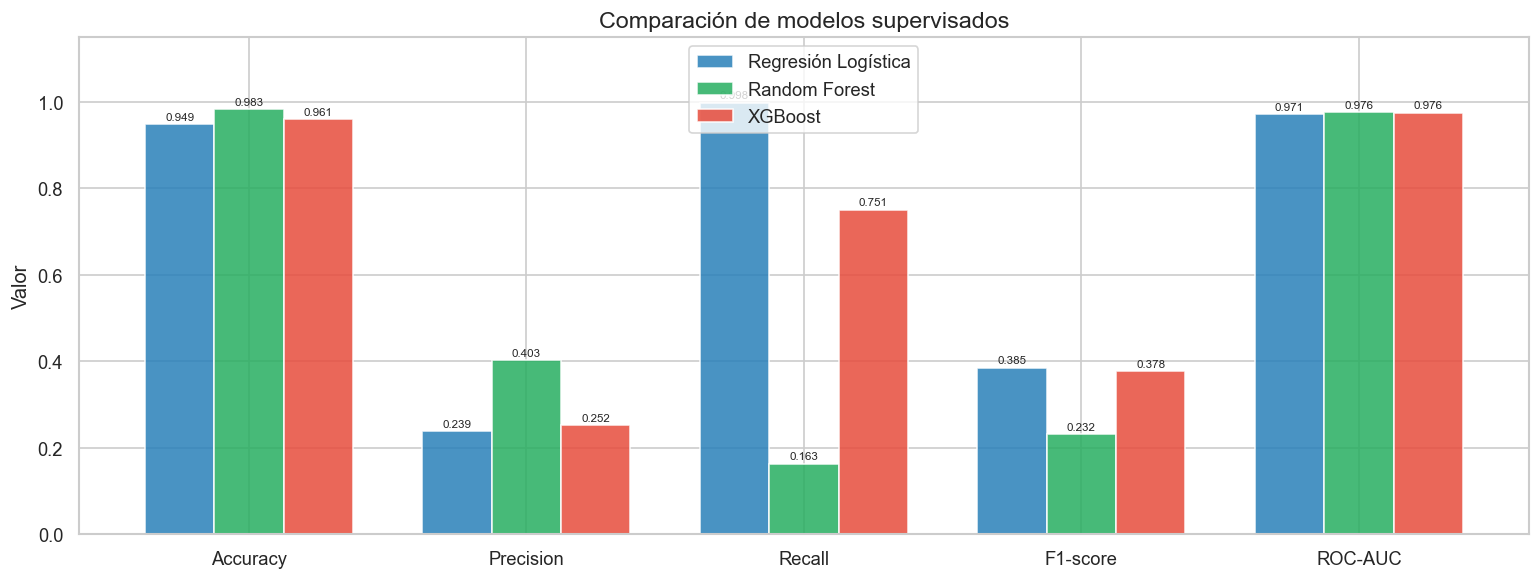

In [49]:
metric_keys = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']
metrics_df  = pd.DataFrame({
    name: {k: v for k, v in vals.items() if k in metric_keys}
    for name, vals in results.items()
}).T
print(metrics_df.to_string())
metrics_df.to_csv(OUTPUT_DIR / 'a6_metricas_modelos.csv')

x      = np.arange(len(metric_keys))
width  = 0.25
colors = ['#2980B9', '#27AE60', '#E74C3C']

fig, ax = plt.subplots(figsize=(13, 5))
for i, (name, vals) in enumerate(results.items()):
    bars = ax.bar(x + i * width, [vals[m] for m in metric_keys], width,
                  label=name, color=colors[i], alpha=0.85)
    for bar, v in zip(bars, [vals[m] for m in metric_keys]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7)
ax.set_xticks(x + width)
ax.set_xticklabels(metric_keys)
ax.set_ylim(0, 1.15)
ax.set_title('Comparación de modelos supervisados', fontsize=14)
ax.set_ylabel('Valor')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'a6_comparacion_modelos.png')
plt.show()


### A6.6 Matrices de confusión y curvas ROC

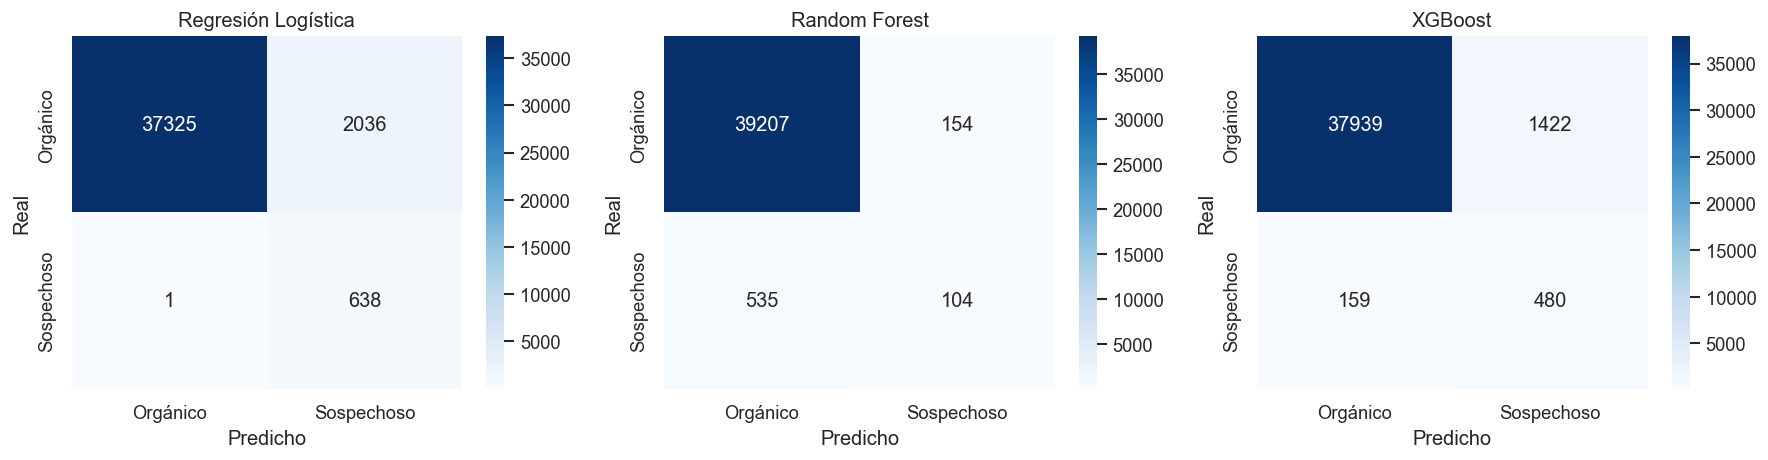

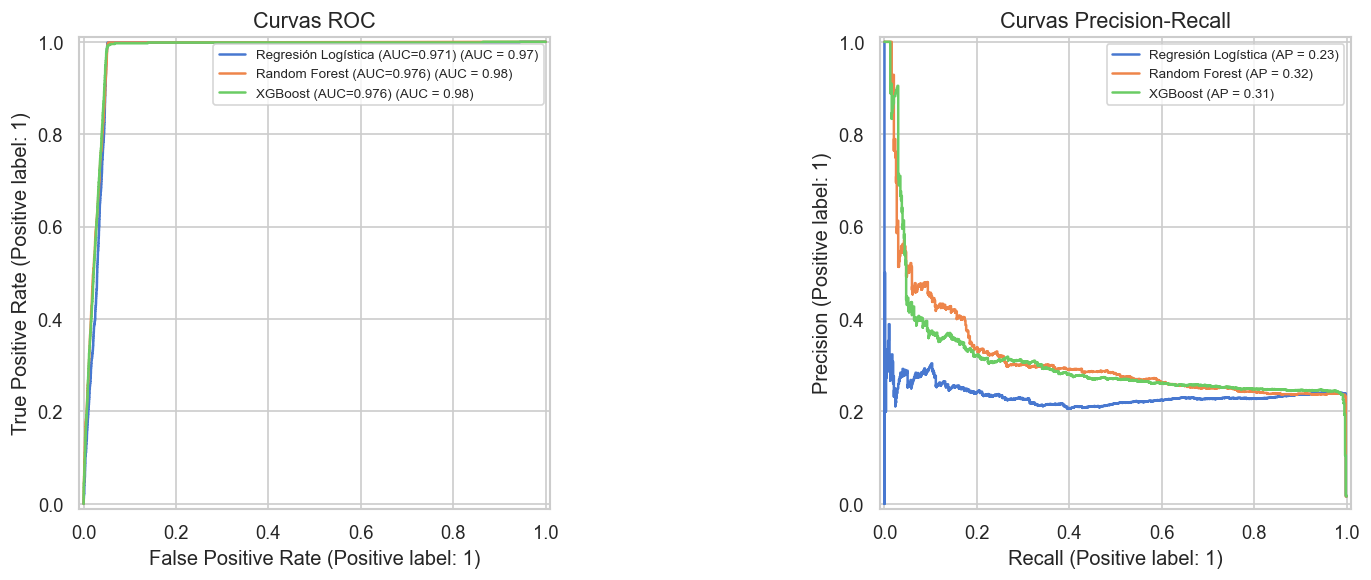

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, vals) in zip(axes, results.items()):
    sns.heatmap(confusion_matrix(y_test, vals['y_pred']), annot=True, fmt='d',
                cmap='Blues', ax=ax,
                xticklabels=['Orgánico', 'Sospechoso'],
                yticklabels=['Orgánico', 'Sospechoso'])
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'a6_matrices_confusion.png')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, vals in results.items():
    RocCurveDisplay.from_predictions(
        y_test, vals['y_proba'], name=f"{name} (AUC={vals['ROC-AUC']:.3f})", ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_test, vals['y_proba'], name=name, ax=axes[1])
axes[0].set_title('Curvas ROC', fontsize=13)
axes[1].set_title('Curvas Precision-Recall', fontsize=13)
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'a6_curvas_roc_pr.png')
plt.show()


### A6.7 Importancia de features e inspección

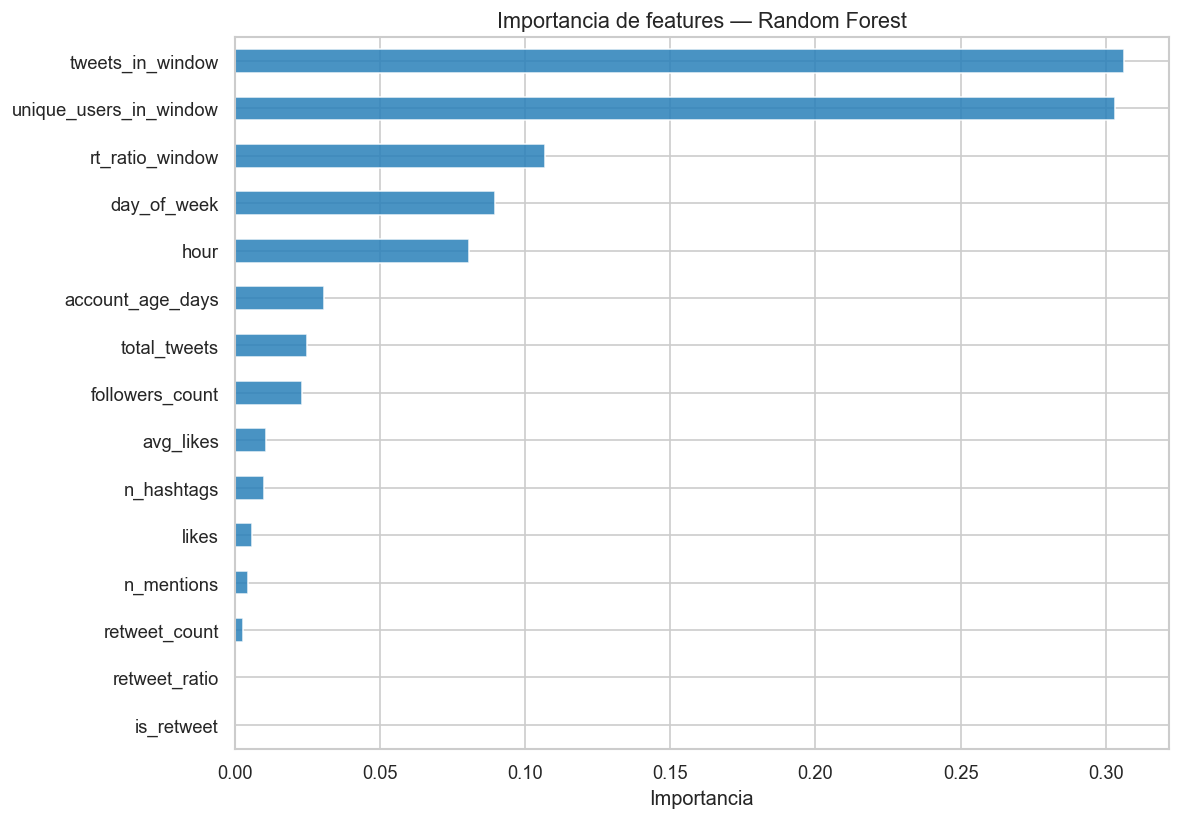

Mejor modelo: Regresión Logística
F1-score: 0.3851 | ROC-AUC: 0.9712

              precision    recall  f1-score   support

    Orgánico       1.00      0.95      0.97     39361
  Sospechoso       0.24      1.00      0.39       639

    accuracy                           0.95     40000
   macro avg       0.62      0.97      0.68     40000
weighted avg       0.99      0.95      0.96     40000


Tweets clasificados como sospechosos: 2,674
                                                                                                                                                                                                                                                                           text user_screen_name                created_at  criterios_cumplidos  tweets_in_window  retweet_ratio
                                                                                                                                                        #Usa2020, #Biden: “Non sono qui per d

In [51]:
rf_importances = pd.Series(
    results['Random Forest']['model'].feature_importances_, index=FEATURE_COLS
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
rf_importances.plot(kind='barh', ax=ax, color='#2980B9', alpha=0.85)
ax.set_title('Importancia de features — Random Forest', fontsize=13)
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'a6_feature_importance.png')
plt.show()

best_name = max(results, key=lambda x: results[x]['F1-score'])
best      = results[best_name]
print(f'Mejor modelo: {best_name}')
print(f'F1-score: {best["F1-score"]:.4f} | ROC-AUC: {best["ROC-AUC"]:.4f}')
print()
print(classification_report(y_test, best['y_pred'], target_names=['Orgánico', 'Sospechoso']))

inspect_cols = [c for c in [
    'text', 'user_screen_name', 'created_at', 'pred_proba', 'criterios_cumplidos',
    'tweets_in_window', 'retweet_ratio',
] if c in df_a6.columns]

df_test = df_a6.iloc[-len(X_test):].copy()
df_test['pred_label'] = best['y_pred']
df_test['pred_proba'] = best['y_proba']
sospechosos = df_test[df_test['pred_label'] == 1].sort_values('pred_proba', ascending=False)
print(f'\nTweets clasificados como sospechosos: {len(sospechosos):,}')
print(sospechosos[inspect_cols].head(10).to_string(index=False))
